# Moss Landing / Peaks MO890 Wave Height XGBoost Regression Model 

This notebook trains an XGBoost regression model to predict observed breaking-wave height for Moss Landing / Peaks using the local observation workbook plus public wave and tide inputs.

The main flow is:

1. Install and import local Python packages.
2. Set the target site, local file paths, enrichment switches, and model parameters.
3. Load the surf-log workbook or CSV inputs.
4. Standardize the personal log into model-ready observations.
5. Enrich observations with CDIP MOP nearshore wave fields, CDIP offshore buoy fields, and NOAA tide fields when available.
6. Build numeric, directional, categorical, and interaction features.
7. Train and validate an XGBoost regression model with a chronological holdout split.
8. Generate MO890 wave-height predictions.
9. Evaluate model performance with regression metrics, residual plots, loss curves, binned accuracy, a confusion matrix, feature importance, and SHAP explanations.


Most of the settings you will edit are in the **Configuration** cell. Advanced feature-selection settings are in the **Feature engineering** section, and advanced evaluation bins are in the **Configuration** cell under `WAVE_HEIGHT_CLASS_BINS` and `WAVE_HEIGHT_CLASS_LABELS`.


## 1. Local Python environment setup


The next code cell installs every Python package that the notebook expects in the active Jupyter kernel. It is safe to run more than once. If a package is already installed, pip usually leaves it alone. Wasnt sure what was installed in my conda environment so i just installed these just incase. 

The important packages are:

- `netCDF4`: opens CDIP THREDDS/OPeNDAP NetCDF files for MOP and buoy wave data.
- `openpyxl`: lets pandas read the Excel workbook.
- `scikit-learn`: provides preprocessing, pipelines, metrics, and train/test workflow.
- `xgboost`: trains the XGBoost regression model.
- `shap`: optional explanation plots for feature impact.
- `joblib`: saves the fitted pipeline to disk.
- `requests`: calls NOAA tide predictions.
- `pytz`: handles Pacific time conversion.
- `matplotlib`: creates plots.

Wasnt sure what was installed in my conda environment so i jsut installed these just incase. 


In [1]:
%pip install -q netCDF4 openpyxl scikit-learn xgboost shap joblib requests pytz structlog matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

**What this code block does**

This is the main control panel for the notebook. It defines the target site, local file names, public-data behavior, model settings, evaluation bins, and output file paths. Most changes you will make should happen here instead of inside the modeling code.

**Most important editable parameters**

| Parameter | What it controls | When to edit it |
|---|---|---|
| `TARGET_CDIP_TRANSECT` | CDIP MOP transect used for the target site. Currently `MO890`. | Change if you want a different CDIP transect. |
| `TARGET_BREAK_NAME` | Break name written into outputs and used for target matching. | Change if you train another break. |
| `TARGET_SPOT_NAME` | Spot name written into outputs and used for target matching. | Change if you train another named spot. |
| `TARGET_BREAK_ID` | Optional explicit break ID. If `None`, the notebook uses a fallback ID. | Set this if you have a real break ID in `breaks.csv`. |
| `TARGET_LAT`, `TARGET_LON` | Location used for nearest tide station matching. | Replace with exact break coordinates if available. |
| `DEFAULT_OBSERVATION_TIME` | Time assigned to workbook rows that do not include a time in notes. | Edit if your log entries are generally morning, afternoon, etc. |
| `LOCAL_DATA_DIR` | Folder where the notebook reads input files and writes outputs. | Edit directly or set `SURF_MODEL_DATA_DIR` before launching Jupyter. |
| `OBSERVATIONS_XLSX` / CSV paths | Input filenames. | Edit if your files have different names. |
| `USE_CACHED_ENRICHED_IF_AVAILABLE` | Uses `observations_with_cdip.csv` if it exists. | Set `False` to ignore the cache. |
| `FORCE_REENRICH_FROM_RAW` | Forces public-data re-fetch from the raw observation workbook/CSV. | Set `True` when you want fresh CDIP/NOAA enrichment. |
| `SAVE_ENRICHED_CACHE_CSV` | Saves the enriched training table locally. | Keep `True` to avoid re-fetching every run. |
| `FETCH_TIDES_FOR_TRAINING` | Adds NOAA tide features to training rows. | Set `False` if tide calls fail or you want to test without tide. |
| `FETCH_BUOY_FOR_TRAINING` | Adds offshore buoy features to training rows. | Set `False` if buoy calls are slow or unavailable. |
| `FETCH_TIDES_FOR_PREDICTION` | Adds tide features to prediction rows. | Set `False` if you want the model to impute tide. |
| `FETCH_BUOY_FOR_PREDICTION` | Adds buoy features to prediction rows. | Set `False` if buoy calls are slow or unavailable. |
| `TARGET_BUOY_IDS` | Offshore CDIP buoys used as fallbacks. Currently `[156, 157]`. | Change if you prefer a different buoy mapping. |
| `PREDICTION_ROWS` | Number of recent MOP rows to predict when no prediction CSV is supplied. | Increase for a longer prediction output. |
| `TEST_FRACTION_BY_TIME` | Fraction of newest observations held out for validation. | Increase for stricter validation; decrease if you have little data. |
| `MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL` | Minimum target rows required before fitting a target-only model. | Lower for small data; raise for more reliable target-specific fitting. |
| `XGBOOST_PARAMS` | Main model hyperparameters. | Tune these to adjust bias, variance, speed, and overfitting. |
| `WAVE_HEIGHT_CLASS_BINS` | Height-bin boundaries used for accuracy/confusion matrix. | Edit if you want different surf-height classes. |
| `OUTPUT_DIR` and output paths | Where model, prediction, and evaluation files are written. | Edit if you want a different output folder or filename. |

**Core XGBoost tuning notes**

- Increase `n_estimators` to allow more trees. This can improve fit but may overfit if too high.
- Lower `learning_rate` for slower, more conservative learning. Pair it with more trees.
- Increase `max_depth` to let trees model more complex interactions. This can overfit small datasets.
- Lower `subsample` or `colsample_bytree` to add randomness and reduce overfitting.
- Change `random_state` only if you want to test run-to-run sensitivity.


In [43]:
from pathlib import Path
import os
import sys

# -----------------------------
# Target site requested by user
# -----------------------------
TARGET_CDIP_TRANSECT = "MO890"
TARGET_BREAK_NAME = "moss landing"
TARGET_SPOT_NAME = "Peaks"

# Leave TARGET_BREAK_ID as None to use a notebook fallback of 890 when breaks.csv is missing.
TARGET_BREAK_ID = None
FALLBACK_TARGET_BREAK_ID = 890

# Approximate Moss Landing coordinates. Replace with exact break coordinates if you have them.
TARGET_LAT = 36.804443
TARGET_LON = -121.786942

# Observation-time convention for workbook rows without a time column.
DEFAULT_OBSERVATION_TIME = "12:00"
KNOWN_DATE_TEXT_REPLACEMENTS = {"2/12/0205": "2/12/2025"}

# -----------------------------
# Local file locations
# -----------------------------
# Default: read/write files from the folder where Jupyter was launched.
# Optional: set environment variable SURF_MODEL_DATA_DIR to point somewhere else.
LOCAL_DATA_DIR = Path(os.environ.get("SURF_MODEL_DATA_DIR", ".")).expanduser().resolve()
SCRIPT_DIR = LOCAL_DATA_DIR
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Primary workbook and CSV fallbacks. The notebook uses the first file that exists.
OBSERVATIONS_XLSX = LOCAL_DATA_DIR / "Peaks Surfing DATA.xlsx"
OBSERVATIONS_CSV = LOCAL_DATA_DIR / "calibration_observations.csv"
OBSERVATIONS_PARSED_CSV = LOCAL_DATA_DIR / "calibration_observations_from_peaks_xlsx.csv"
OBSERVATIONS_ALT_CSV = LOCAL_DATA_DIR / "observations.csv"

# Optional local reference CSV files. The notebook can run without these by using the fallback site metadata below.
BREAKS_CSV = LOCAL_DATA_DIR / "breaks.csv"
SPOTS_CSV = LOCAL_DATA_DIR / "spots.csv"
TRANSECT_TO_BUOY_MAP_CSV = LOCAL_DATA_DIR / "transect_to_buoy_map.csv"
TIDE_STATIONS_CSV = LOCAL_DATA_DIR / "tide_stations.csv"
CACHED_ENRICHED_CSV = LOCAL_DATA_DIR / "observations_with_cdip.csv"
PREDICTION_FEATURES_CSV = LOCAL_DATA_DIR / "mo890_prediction_features.csv"

# Enrichment behavior.
USE_CACHED_ENRICHED_IF_AVAILABLE = True
FORCE_REENRICH_FROM_RAW = False
SAVE_ENRICHED_CACHE_CSV = True
USE_LOCAL_CDIP_SCRIPT_IF_AVAILABLE = True
FETCH_TIDES_FOR_TRAINING = True
FETCH_BUOY_FOR_TRAINING = True
FETCH_TIDES_FOR_PREDICTION = True
FETCH_BUOY_FOR_PREDICTION = True

# Public-data fallbacks when optional CSV maps are missing.
USE_DEFAULT_MOSS_LANDING_TIDE_STATION = True
DEFAULT_TIDE_STATION = {"id": "9413616", "name": "Moss Landing, CA", "lat": TARGET_LAT, "lon": TARGET_LON}

# CDIP 156 is Monterey Canyon Outer, near Moss Landing. 157 is a broader fallback if 156 has no row near a date.
TARGET_BUOY_IDS = [156, 157]

# Prediction horizon/source settings.
PREDICTION_ROWS = 168

# Modeling settings.
TEST_FRACTION_BY_TIME = 0.20
MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL = 20
RANDOM_STATE = 42

# XGBoost settings adapted from the provided MS 285 XGBoost notebook.
XGBOOST_PARAMS = {
    "n_estimators": 600,
    "max_depth": 5,
    "random_state": 51,
    "learning_rate": 0.01,
    "subsample": 0.6,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_jobs": 1,
}

# Optional classification-style bins for accuracy/confusion matrix evaluation.
WAVE_HEIGHT_CLASS_BINS = [0, 1, 2, 3, 4, 6, float("inf")]
WAVE_HEIGHT_CLASS_LABELS = ["0-1 ft", "1-2 ft", "2-3 ft", "3-4 ft", "4-6 ft", "6+ ft"]

# Output paths.
OUTPUT_DIR = LOCAL_DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_OUTPUT_PATH = OUTPUT_DIR / "mo890_wave_height_xgboost_model.joblib"
METADATA_OUTPUT_PATH = OUTPUT_DIR / "mo890_wave_height_model_metadata.json"
PREDICTIONS_OUTPUT_PATH = OUTPUT_DIR / "mo890_wave_height_predictions.csv"
EVAL_PREDICTIONS_OUTPUT_PATH = OUTPUT_DIR / "mo890_model_evaluation_holdout_predictions.csv"
EVAL_METRICS_OUTPUT_PATH = OUTPUT_DIR / "mo890_model_evaluation_metrics.json"
CONFUSION_MATRIX_OUTPUT_PATH = OUTPUT_DIR / "mo890_wave_height_bin_confusion_matrix.csv"

print("Target:", TARGET_CDIP_TRANSECT, TARGET_BREAK_NAME, TARGET_SPOT_NAME)
print("Data directory:", LOCAL_DATA_DIR)
print("Output directory:", OUTPUT_DIR)

Target: MO890 moss landing Peaks
Data directory: /Users/masonjones/Desktop/explainedNotebook
Output directory: /Users/masonjones/Desktop/explainedNotebook/outputs


## 3. Locate local input files


The next code cell prints which expected files are present in `LOCAL_DATA_DIR`. It checks the raw workbook, several CSV alternatives, optional metadata files, an optional enriched cache, and an optional prediction-feature CSV.

The cell also stops the notebook early with a clear error if none of the observation inputs can be found. This prevents later sections from failing with less obvious messages.

**Editable parameters**

The file names are controlled in the Configuration cell, not here. Edit `OBSERVATIONS_XLSX`, `OBSERVATIONS_CSV`, `BREAKS_CSV`, `TIDE_STATIONS_CSV`, `CACHED_ENRICHED_CSV`, or `PREDICTION_FEATURES_CSV` if your local files use different names.


In [44]:
print("Reading files from:", LOCAL_DATA_DIR)

expected = [
    OBSERVATIONS_XLSX, OBSERVATIONS_CSV, OBSERVATIONS_PARSED_CSV, OBSERVATIONS_ALT_CSV,
    BREAKS_CSV, SPOTS_CSV, TRANSECT_TO_BUOY_MAP_CSV, TIDE_STATIONS_CSV,
    CACHED_ENRICHED_CSV, PREDICTION_FEATURES_CSV,
]
for path in expected:
    print(("FOUND   " if path.exists() else "missing ") + path.name)

if not any(p.exists() for p in [OBSERVATIONS_XLSX, OBSERVATIONS_CSV, OBSERVATIONS_PARSED_CSV, OBSERVATIONS_ALT_CSV]):
    raise FileNotFoundError(
        "No observation input found. Put 'Peaks Surfing DATA.xlsx', 'calibration_observations.csv', "
        "'calibration_observations_from_peaks_xlsx.csv', or 'observations.csv' in LOCAL_DATA_DIR."
    )

Reading files from: /Users/masonjones/Desktop/explainedNotebook
FOUND   Peaks Surfing DATA.xlsx
missing calibration_observations.csv
FOUND   calibration_observations_from_peaks_xlsx.csv
missing observations.csv
missing breaks.csv
missing spots.csv
missing transect_to_buoy_map.csv
missing tide_stations.csv
FOUND   observations_with_cdip.csv
missing mo890_prediction_features.csv


## 4. Imports and optional local script hooks

**What this code block does**

This cell imports all Python libraries used by the rest of the notebook. It also checks whether helper scripts such as `fetch_historical_cdip.py` are available in the notebook folder or configured data folder.

If the helper script imports successfully, the notebook can reuse that script's CDIP MOP fetch function. If it does not import successfully, the notebook uses its own built-in local helper functions defined later. Either path keeps the workflow runnable locally.

The cell also reports the installed XGBoost version and whether SHAP is available.

**Editable parameters**

- `USE_LOCAL_CDIP_SCRIPT_IF_AVAILABLE` in the Configuration cell controls whether the notebook tries to use `fetch_historical_cdip.py`.
- You normally should not edit the imports unless you add new features, plots, or model types.


In [45]:
import json
import math
import re
import time
import hashlib
import warnings
from datetime import datetime, timezone, timedelta
from typing import Optional, Iterable

import numpy as np
import pandas as pd
import pytz
import requests
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    max_error,
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib
import xgboost as xgb

try:
    import shap
except Exception as shap_import_error:
    shap = None
    print("SHAP is not available; XGBoost training will still work.")
    print("SHAP import note:", shap_import_error)

warnings.filterwarnings("ignore", category=FutureWarning)

# Make local helper scripts importable if they are in the notebook folder or configured data folder.
for candidate in [Path.cwd(), LOCAL_DATA_DIR, SCRIPT_DIR]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

production_fetch_cdip_mop_data = None
production_enrich_cdip_mop = None

if USE_LOCAL_CDIP_SCRIPT_IF_AVAILABLE:
    try:
        from fetch_historical_cdip import (  # type: ignore
            fetch_cdip_mop_data as production_fetch_cdip_mop_data,
            enrich_observations_with_cdip_mop as production_enrich_cdip_mop,
        )
        print("Loaded local fetch_historical_cdip.py helpers.")
    except Exception as script_error:
        print("Local fetch_historical_cdip.py not available or not importable; using notebook fallback.")
        print("Import note:", script_error)

print("production_fetch_cdip_mop_data:", production_fetch_cdip_mop_data is not None)
print("xgboost version:", xgb.__version__)
print("SHAP available:", shap is not None)


Loaded local fetch_historical_cdip.py helpers.
production_fetch_cdip_mop_data: True
xgboost version: 3.1.2
SHAP available: True


## 5. Load raw inputs

**What this code block does**

This block defines and runs the input-loading functions. It can read:

- `Peaks Surfing DATA.xlsx` directly, including all sheets.
- `calibration_observations.csv` as a raw observation CSV.
- `calibration_observations_from_peaks_xlsx.csv` as a pre-parsed observation CSV.
- `observations.csv` as another fallback.
- Optional `breaks.csv`, `spots.csv`, `transect_to_buoy_map.csv`, `tide_stations.csv`, and `observations_with_cdip.csv`.

It normalizes column names so variations like `Break Name`, `break_name`, and `break/name` are easier to work with. If `breaks.csv` is missing, it creates a one-row Moss Landing / Peaks metadata table using the target settings from the Configuration cell. If `tide_stations.csv` is missing, it can create a default Moss Landing tide-station row.

At the end, it displays the shapes and first rows of the loaded data so you can confirm the notebook is reading what you expect.

**Editable parameters**

- Edit file path variables in the Configuration cell if your files have different names.
- Edit `TARGET_LAT`, `TARGET_LON`, and `DEFAULT_TIDE_STATION` if the fallback metadata should be more precise.
- Add real `breaks.csv` and `tide_stations.csv` files if you want the notebook to use your own metadata instead of fallbacks.


In [46]:
def load_csv_if_exists(path: Path, parse_dates: Optional[list[str]] = None) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path, parse_dates=parse_dates)
    return pd.DataFrame()


def _normalize_name_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    normalized_cols = [
        re.sub(r"_+", "_", str(c).strip().lower().replace("\n", " ").replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "")).strip("_")
        for c in out.columns
    ]
    out.columns = normalized_cols

    # Excel workbooks sometimes have Date/DATE or Notes/NOTES from different sheets.
    # After normalization those become duplicate names; coalesce duplicates by taking
    # the first non-null value across the duplicate columns on each row.
    if out.columns.duplicated().any():
        pieces = {}
        for col in dict.fromkeys(out.columns):
            same_name = out.loc[:, out.columns == col]
            if same_name.shape[1] == 1:
                pieces[col] = same_name.iloc[:, 0]
            else:
                pieces[col] = same_name.bfill(axis=1).iloc[:, 0]
        out = pd.DataFrame(pieces, index=out.index)
    return out


def _minimal_target_breaks_df() -> pd.DataFrame:
    return pd.DataFrame([{
        "break_id": TARGET_BREAK_ID if TARGET_BREAK_ID is not None else FALLBACK_TARGET_BREAK_ID,
        "break_name": TARGET_BREAK_NAME,
        "spot_name": TARGET_SPOT_NAME,
        "cdip_transect": TARGET_CDIP_TRANSECT,
        "lat": TARGET_LAT,
        "lon": TARGET_LON,
        "tide_station_id": DEFAULT_TIDE_STATION["id"],
    }])


def load_observations_input() -> tuple[pd.DataFrame, str]:
    if OBSERVATIONS_XLSX.exists():
        sheets = pd.read_excel(OBSERVATIONS_XLSX, sheet_name=None, engine="openpyxl")
        frames = []
        for sheet_name, sheet_df in sheets.items():
            part = sheet_df.copy()
            part["source_sheet"] = sheet_name
            frames.append(part)
        return pd.concat(frames, ignore_index=True), OBSERVATIONS_XLSX.name
    if OBSERVATIONS_CSV.exists():
        return pd.read_csv(OBSERVATIONS_CSV), OBSERVATIONS_CSV.name
    if OBSERVATIONS_PARSED_CSV.exists():
        return pd.read_csv(OBSERVATIONS_PARSED_CSV), OBSERVATIONS_PARSED_CSV.name
    if OBSERVATIONS_ALT_CSV.exists():
        return pd.read_csv(OBSERVATIONS_ALT_CSV), OBSERVATIONS_ALT_CSV.name
    return pd.DataFrame(), ""


def load_inputs() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, str]:
    observations_df, observation_source = load_observations_input()
    breaks_df = load_csv_if_exists(BREAKS_CSV)
    spots_df = load_csv_if_exists(SPOTS_CSV)
    transect_to_buoy_df = load_csv_if_exists(TRANSECT_TO_BUOY_MAP_CSV)
    tide_stations_df = load_csv_if_exists(TIDE_STATIONS_CSV)
    cached_enriched_df = load_csv_if_exists(CACHED_ENRICHED_CSV)

    if not breaks_df.empty:
        breaks_df = _normalize_name_columns(breaks_df)
    if not spots_df.empty:
        spots_df = _normalize_name_columns(spots_df)

    # If breaks only has spot_id, join spots.csv to get spot_name.
    if (
        not breaks_df.empty
        and not spots_df.empty
        and "spot_id" in breaks_df.columns
        and "id" in spots_df.columns
        and "spot_name" not in breaks_df.columns
    ):
        spots_name_col = "name" if "name" in spots_df.columns else "spot_name"
        breaks_df = breaks_df.merge(
            spots_df[["id", spots_name_col]].rename(columns={"id": "spot_id", spots_name_col: "spot_name"}),
            on="spot_id",
            how="left",
        )

    if observations_df.empty and cached_enriched_df.empty:
        raise ValueError(
            "No training observations were loaded. Provide Peaks Surfing DATA.xlsx, "
            "calibration_observations.csv, observations.csv, or observations_with_cdip.csv."
        )

    if breaks_df.empty:
        print("breaks.csv not found. Using one-row Moss Landing / Peaks target metadata from configuration.")
        breaks_df = _minimal_target_breaks_df()

    if tide_stations_df.empty and USE_DEFAULT_MOSS_LANDING_TIDE_STATION:
        tide_stations_df = pd.DataFrame([DEFAULT_TIDE_STATION])
        print("tide_stations.csv not found. Using default Moss Landing NOAA tide station metadata.")

    return observations_df, breaks_df, transect_to_buoy_df, tide_stations_df, cached_enriched_df, observation_source


observations_raw, breaks_raw, transect_to_buoy_raw, tide_stations_raw, cached_enriched_raw, observation_source = load_inputs()

print("observation_source:", observation_source or "cache only")
print("observations_raw:", observations_raw.shape)
print("breaks_raw:", breaks_raw.shape)
print("transect_to_buoy_raw:", transect_to_buoy_raw.shape)
print("tide_stations_raw:", tide_stations_raw.shape)
print("cached_enriched_raw:", cached_enriched_raw.shape)

if not observations_raw.empty:
    display(observations_raw.head(5))
display(breaks_raw.head(3))
if not cached_enriched_raw.empty:
    display(cached_enriched_raw.head(3))


breaks.csv not found. Using one-row Moss Landing / Peaks target metadata from configuration.
tide_stations.csv not found. Using default Moss Landing NOAA tide station metadata.
observation_source: Peaks Surfing DATA.xlsx
observations_raw: (22, 16)
breaks_raw: (1, 7)
transect_to_buoy_raw: (0, 0)
tide_stations_raw: (1, 4)
cached_enriched_raw: (22, 46)


,Date,Place,With who,Wave Yumminess (visually apealing),Makeablility,Barrels Made,Swell,Time out (Hrs),Craft,Notes,source_sheet,DATE,PLACE,WITH WHO,SWELL,NOTES
0,2024-08-20 00:00:00,Peaks,self,7.0,4.0,1.0,4.1ft @4s NW,0.5,Bodysurf,Bodysurfed 2ft,Sheet1,NaT,NaN,NaN,NaN,NaN
1,2024-08-21 00:00:00,Peaks,self,6.0,5.0,1.0,Bunch of south swells,0.5,Bodysurf,Bodysurfed and got 1 crazy tube 2-3ft,Sheet1,NaT,NaN,NaN,NaN,NaN
2,2024-08-28 00:00:00,Peaks,self,9.0,6.0,0.0,5ft @7s NW,1.0,Boog,Booged/ some beuts but never in the right spot...,Sheet1,NaT,NaN,NaN,NaN,NaN
3,2024-10-01 00:00:00,Peaks,Self,7.0,4.0,1.0,NW@6ish,1.0,Boog,Lil shifty but the right peaky wedge is still ...,Sheet1,NaT,NaN,NaN,NaN,NaN
4,2024-10-08 00:00:00,Peaks,Self/enok,7.0,6.0,3.0,NW@7ish,1.0,Boog,"Smaller than hoped, 3-4 but still some crazy o...",Sheet1,NaT,NaN,NaN,NaN,NaN


,break_id,break_name,spot_name,cdip_transect,lat,lon,tide_station_id
0,890,moss landing,Peaks,MO890,36.804443,-121.786942,9413616


,date,place,with_who,wave_yumminess_visually_apealing,makeablility,barrels_made,swell,time_out_hrs,craft,notes,...,per_sec_s_buoy,dir_pri_deg_buoy,dir_sec_deg_buoy,dir_mean_deg_buoy,per_weighted_s_buoy,tm10_s,energy_low_freq_buoy,energy_short_freq_buoy,buoy_id,tide_ft
0,2024-08-20 00:00:00,Peaks,self,7.0,4.0,1.0,4.1ft @4s NW,0.5,Bodysurf,Bodysurfed 2ft,...,NaN,186.978027,NaN,251.829588,8.011953,8.011953,0.016559,0.044138,157,NaN
1,2024-08-21 00:00:00,Peaks,self,6.0,5.0,1.0,Bunch of south swells,0.5,Bodysurf,Bodysurfed and got 1 crazy tube 2-3ft,...,NaN,200.076904,NaN,282.337807,6.841361,6.841361,0.009940,0.053141,157,NaN
2,2024-08-28 00:00:00,Peaks,self,9.0,6.0,0.0,5ft @7s NW,1.0,Boog,Booged/ some beuts but never in the right spot...,...,NaN,319.968018,NaN,315.521244,8.635177,8.635177,0.010158,0.348394,157,NaN


## 6. Standardize the personal surf log into model observations

This block converts the personal surf log into a standardized observation table that the enrichment and model sections can use.

Main jobs performed here:

1. Normalize column names.
2. Parse dates from Excel serial numbers or text date strings.
3. Parse session times from notes when possible, such as `815-915am` or `8am`.
4. Use `DEFAULT_OBSERVATION_TIME` when no time is found.
5. Parse observed breaking-wave height from notes, including values like `2-3ft`, `3-4+`, and `Flat`.
6. Parse the workbook `Swell` text into fallback physical features: height, period, direction text, and direction degrees.
7. Attach Moss Landing / Peaks metadata to every observation row.
8. Drop rows that do not have both a valid timestamp and an observed wave-height target.

This section creates the supervised-learning target column, `observed_hs_ft`. That is the value the XGBoost model learns to predict.

**Editable parameters and advanced edits**

- `DEFAULT_OBSERVATION_TIME`: change this if log rows usually represent a different time of day.
- `KNOWN_DATE_TEXT_REPLACEMENTS`: add typo fixes for unusual date strings.
- `parse_observed_height_from_notes`: edit this if your notes use different wave-height wording.
- `parse_time_from_notes`: edit this if your notes use a different time style.
- `parse_swell_text`: edit this if your swell text has a different format.
- `COMPASS_TO_DEG`: edit or extend if you need more direction aliases.

For model quality, the most important thing here is accurate `observed_hs_ft`. If the parser misreads your notes, fix this section or add a clean `observed_hs_ft` column to your input CSV.


In [47]:
PST = pytz.timezone("US/Pacific")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    return _normalize_name_columns(df)


def parse_wave_height_value(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float, np.number)):
        return float(v)
    s = str(v).strip().lower().replace("feet", "ft")
    if s in {"flat", "lake", "none", "0"}:
        return 0.0
    s_clean = s.replace("ft", "").strip()
    if "-" in s_clean:
        parts = [p.strip().replace("+", "") for p in s_clean.split("-", 1)]
        try:
            base = (float(parts[0]) + float(parts[1])) / 2
            return base + (0.25 if "+" in s else 0.0)
        except Exception:
            return np.nan
    try:
        base = float(s_clean.replace("+", ""))
        return base + (0.25 if "+" in s else 0.0)
    except Exception:
        return np.nan


def parse_observed_height_from_notes(notes: object, swell_text: object = None) -> float:
    """Extract the last plausible wave-height mention from notes; fallback to 'Flat' in swell text."""
    text = "" if pd.isna(notes) else str(notes)
    text_l = text.lower()

    # Ranges: 2-3ft, 3-4+, 1-2+ft, or 3-4 with bigger sets.
    range_pattern = re.compile(r"(?<!\d)(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)(\+)?\s*(?:ft|feet)?(?!\s*(?:am|pm))", re.I)
    candidates = []
    for m in range_pattern.finditer(text_l):
        lo, hi = float(m.group(1)), float(m.group(2))
        if 0 <= lo <= hi <= 30:
            value = (lo + hi) / 2 + (0.25 if m.group(3) else 0.0)
            candidates.append((m.start(), value, f"{m.group(0)}"))

    # Singles: 2ft, 4+ft. Ignore obvious tide mentions when another candidate appears later.
    single_pattern = re.compile(r"(?<!\d)(\d+(?:\.\d+)?)(\+)?\s*ft", re.I)
    for m in single_pattern.finditer(text_l):
        value = float(m.group(1)) + (0.25 if m.group(2) else 0.0)
        if 0 <= value <= 30:
            candidates.append((m.start(), value, f"{m.group(0)}"))

    if candidates:
        candidates = sorted(candidates, key=lambda x: x[0])
        return float(candidates[-1][1])

    if isinstance(swell_text, str) and swell_text.strip().lower() == "flat":
        return 0.0
    return np.nan


def parse_excel_or_text_date(value) -> pd.Timestamp:
    if pd.isna(value):
        return pd.NaT
    if isinstance(value, (int, float, np.number)) and not isinstance(value, bool):
        # Excel serial date convention used by pandas/openpyxl.
        return pd.Timestamp("1899-12-30") + pd.to_timedelta(float(value), unit="D")
    text = str(value).strip()
    text = KNOWN_DATE_TEXT_REPLACEMENTS.get(text, text)
    m = re.match(r"^(\d{1,2})[/-](\d{1,2})[/-](\d{2,4})$", text)
    if m:
        month, day, year_text = m.groups()
        if year_text == "0205":
            year_text = "2025"
        elif len(year_text) == 2:
            year_text = "20" + year_text
        text = f"{month}/{day}/{year_text}"
    return pd.to_datetime(text, errors="coerce")


def _time_token_to_hour_minute(token: str) -> tuple[int, int]:
    digits = re.sub(r"\D", "", token)
    if len(digits) <= 2:
        return int(digits), 0
    if len(digits) == 3:
        return int(digits[0]), int(digits[1:])
    return int(digits[:-2]), int(digits[-2:])


def parse_time_from_notes(notes: object, default_time: str = DEFAULT_OBSERVATION_TIME) -> tuple[str, str]:
    text = "" if pd.isna(notes) else str(notes).lower()
    # Examples: 815-915am, 8:15-9:15am, 8am.
    range_m = re.search(r"\b(\d{1,4}(?::\d{2})?)\s*[-–]\s*(\d{1,4}(?::\d{2})?)\s*(am|pm)\b", text)
    if range_m:
        token = range_m.group(1)
        meridiem = range_m.group(3)
        hour, minute = _time_token_to_hour_minute(token)
        if meridiem == "pm" and hour != 12:
            hour += 12
        if meridiem == "am" and hour == 12:
            hour = 0
        if 0 <= hour <= 23 and 0 <= minute <= 59:
            return f"{hour:02d}:{minute:02d}", "parsed_from_notes"
    single_m = re.search(r"\b(\d{1,2})(?::(\d{2}))?\s*(am|pm)\b", text)
    if single_m:
        hour = int(single_m.group(1))
        minute = int(single_m.group(2) or 0)
        meridiem = single_m.group(3)
        if meridiem == "pm" and hour != 12:
            hour += 12
        if meridiem == "am" and hour == 12:
            hour = 0
        return f"{hour:02d}:{minute:02d}", "parsed_from_notes"
    return default_time, "default_time"



COMPASS_TO_DEG = {
    "n": 0.0, "nne": 22.5, "ne": 45.0, "ene": 67.5,
    "e": 90.0, "ese": 112.5, "se": 135.0, "sse": 157.5,
    "s": 180.0, "ssw": 202.5, "sw": 225.0, "wsw": 247.5,
    "w": 270.0, "wnw": 292.5, "nw": 315.0, "nnw": 337.5,
    "north": 0.0, "east": 90.0, "south": 180.0, "west": 270.0,
}


def parse_swell_text(swell_text: object) -> dict:
    """Parse height, period, and direction from the workbook Swell field.

    Examples handled: '4.1ft @4s NW', 'WNW@302 11sec 5ft', 'SW@260 14sec',
    'NW@16s', and 'Bunch of south swells'.
    """
    out = {
        "swell_height_ft": np.nan,
        "swell_period_s": np.nan,
        "swell_direction_text": None,
        "swell_direction_deg": np.nan,
    }
    if pd.isna(swell_text):
        return out
    s_raw = str(swell_text)
    s = s_raw.lower().replace("seconds", "sec").replace("second", "sec")

    if s.strip() == "flat":
        out["swell_height_ft"] = 0.0
        return out

    h_matches = list(re.finditer(r"(\d+(?:\.\d+)?)\s*ft\b", s))
    if h_matches:
        out["swell_height_ft"] = float(h_matches[-1].group(1))

    p_matches = list(re.finditer(r"(\d+(?:\.\d+)?)\s*(?:s|sec)\b", s))
    if p_matches:
        out["swell_period_s"] = float(p_matches[-1].group(1))

    # Prefer explicit numeric bearing after @ when present, e.g. SW@260 14sec.
    bearing_matches = list(re.finditer(r"@\s*(\d{2,3})(?!\s*(?:ft|s|sec))", s))
    if bearing_matches:
        val = float(bearing_matches[-1].group(1))
        if 0 <= val <= 360:
            out["swell_direction_deg"] = val

    # Compass words/tokens. Longest first so WNW is not shortened to W.
    for token in sorted(COMPASS_TO_DEG.keys(), key=len, reverse=True):
        if re.search(rf"\b{re.escape(token)}\b", s):
            out["swell_direction_text"] = token.upper() if len(token) <= 3 else token
            if pd.isna(out["swell_direction_deg"]):
                out["swell_direction_deg"] = COMPASS_TO_DEG[token]
            break
    return out

def prepare_personal_surf_log_observations(obs_df: pd.DataFrame) -> pd.DataFrame:
    obs = normalize_columns(obs_df)
    obs = obs.dropna(how="all").copy()

    # Map common workbook columns.
    if "date" not in obs.columns:
        raise ValueError("The observations workbook/CSV needs a Date/date column.")
    if "place" not in obs.columns and "spot" not in obs.columns and "break" not in obs.columns:
        obs["place"] = TARGET_SPOT_NAME
    if "notes" not in obs.columns:
        obs["notes"] = ""
    if "swell" not in obs.columns and "swell_" in obs.columns:
        obs["swell"] = obs["swell_"]

    obs["date_parsed"] = obs["date"].apply(parse_excel_or_text_date)
    time_parsed = obs["notes"].apply(parse_time_from_notes)
    obs["time"] = time_parsed.apply(lambda x: x[0])
    obs["time_source"] = time_parsed.apply(lambda x: x[1])
    obs["datetime_pst"] = pd.to_datetime(obs["date_parsed"].dt.strftime("%Y-%m-%d") + " " + obs["time"], errors="coerce")
    obs["datetime_pst"] = obs["datetime_pst"].apply(lambda x: PST.localize(x) if pd.notna(x) and x.tzinfo is None else x)

    if "observed_hs_ft" not in obs.columns:
        swell_series = obs["swell"] if "swell" in obs.columns else pd.Series([None] * len(obs), index=obs.index)
        obs["observed_hs_ft"] = [parse_observed_height_from_notes(n, s) for n, s in zip(obs["notes"], swell_series)]
    else:
        obs["observed_hs_ft"] = obs["observed_hs_ft"].apply(parse_wave_height_value)

    # Parse the free-text Swell column into physical features that can be used as fallback inputs.
    if "swell" in obs.columns:
        parsed_swell = pd.DataFrame([parse_swell_text(v) for v in obs["swell"]], index=obs.index)
        for col in parsed_swell.columns:
            obs[col] = parsed_swell[col]
    else:
        obs["swell_height_ft"] = np.nan
        obs["swell_period_s"] = np.nan
        obs["swell_direction_text"] = None
        obs["swell_direction_deg"] = np.nan

    # The local log's Place column is the spot name. The requested break name is Moss Landing.
    obs["break_id"] = TARGET_BREAK_ID if TARGET_BREAK_ID is not None else FALLBACK_TARGET_BREAK_ID
    obs["break"] = TARGET_BREAK_NAME
    obs["spot"] = TARGET_SPOT_NAME
    obs["break_name"] = TARGET_BREAK_NAME
    obs["spot_name"] = TARGET_SPOT_NAME
    obs["cdip_transect"] = TARGET_CDIP_TRANSECT
    obs["lat"] = TARGET_LAT
    obs["lon"] = TARGET_LON

    before = len(obs)
    obs = obs.dropna(subset=["datetime_pst", "observed_hs_ft"]).copy()
    print(f"Prepared personal-log observations: kept {len(obs)} of {before} non-empty rows with date and observed wave height.")
    return obs


def _coerce_break_key(value):
    if pd.isna(value):
        return None
    try:
        f = float(value)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return str(value).strip()


def _localize_or_convert_to_pst(value):
    if pd.isna(value):
        return pd.NaT
    ts = pd.Timestamp(value)
    if ts.tzinfo is None:
        return PST.localize(ts.to_pydatetime())
    return ts.tz_convert(PST)


def ensure_datetime_pst(obs_df: pd.DataFrame) -> pd.DataFrame:
    df = obs_df.copy()
    if "datetime_pst" in df.columns:
        parsed = pd.to_datetime(df["datetime_pst"], errors="coerce")
        if pd.api.types.is_datetime64tz_dtype(parsed):
            df["datetime_pst"] = parsed.dt.tz_convert(PST)
        elif pd.api.types.is_datetime64_any_dtype(parsed):
            df["datetime_pst"] = parsed.apply(_localize_or_convert_to_pst)
        else:
            parsed_utc = pd.to_datetime(df["datetime_pst"], errors="coerce", utc=True)
            df["datetime_pst"] = parsed_utc.dt.tz_convert(PST)
        return df
    if "observed_at" in df.columns:
        dt = pd.to_datetime(df["observed_at"], errors="coerce", utc=True)
        df["datetime_pst"] = dt.dt.tz_convert(PST)
        return df
    if "timestamp" in df.columns:
        dt = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
        df["datetime_pst"] = dt.dt.tz_convert(PST)
        return df
    if "date" in df.columns and "time" in df.columns:
        dt = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str), errors="coerce")
        df["datetime_pst"] = dt.apply(_localize_or_convert_to_pst)
        return df
    raise ValueError("Observations need datetime_pst, observed_at, timestamp, or date+time columns.")


def prepare_observations_and_breaks(obs_df: pd.DataFrame, breaks_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    breaks = normalize_columns(breaks_df)
    if "id" in breaks.columns and "break_id" not in breaks.columns:
        breaks["break_id"] = breaks["id"]
    if "name" in breaks.columns and "break_name" not in breaks.columns:
        breaks["break_name"] = breaks["name"]
    if "lng" in breaks.columns and "lon" not in breaks.columns:
        breaks["lon"] = breaks["lng"]

    obs = normalize_columns(obs_df)
    looks_like_personal_log = "notes" in obs.columns and "date" in obs.columns and ("place" in obs.columns or "swell" in obs.columns or "swell_" in obs.columns)
    if looks_like_personal_log and "observed_hs_ft" not in obs.columns:
        obs = prepare_personal_surf_log_observations(obs_df)
    else:
        if "spot" not in obs.columns:
            if "place" in obs.columns:
                obs["spot"] = obs["place"]
            elif "break" in obs.columns:
                obs["spot"] = obs["break"]
        if "break" not in obs.columns:
            obs["break"] = TARGET_BREAK_NAME if "place" in obs.columns else obs.get("spot", TARGET_BREAK_NAME)
        if "break_id" not in obs.columns:
            obs["break_id"] = TARGET_BREAK_ID if TARGET_BREAK_ID is not None else FALLBACK_TARGET_BREAK_ID
        obs = ensure_datetime_pst(obs)
        for col in ["observed_hs_ft", "wave_height_ft", "observed_height_ft"]:
            if col in obs.columns:
                obs["observed_hs_ft"] = obs[col].apply(parse_wave_height_value)
                break
        if "observed_hs_ft" not in obs.columns:
            raise ValueError("Observations need observed_hs_ft/wave_height_ft, or notes that include wave heights.")

    return obs, breaks


# Build standardized observations unless an enriched cache is the only source.
if not observations_raw.empty:
    observations_prepared, breaks_prepared = prepare_observations_and_breaks(observations_raw, breaks_raw)
else:
    observations_prepared = pd.DataFrame()
    breaks_prepared = normalize_columns(breaks_raw)

display(observations_prepared[["datetime_pst", "break", "spot", "observed_hs_ft", "notes"]].head(10) if not observations_prepared.empty and "notes" in observations_prepared.columns else observations_prepared.head())
print("Prepared observation rows:", len(observations_prepared))


Prepared personal-log observations: kept 22 of 22 non-empty rows with date and observed wave height.


,datetime_pst,break,spot,observed_hs_ft,notes
0,2024-08-20 12:00:00-07:00,moss landing,Peaks,2.00,Bodysurfed 2ft
1,2024-08-21 12:00:00-07:00,moss landing,Peaks,3.00,Bodysurfed and got 1 crazy tube 2-3ft
2,2024-08-28 12:00:00-07:00,moss landing,Peaks,2.75,Booged/ some beuts but never in the right spot...
3,2024-10-01 12:00:00-07:00,moss landing,Peaks,3.00,Lil shifty but the right peaky wedge is still ...
4,2024-10-08 12:00:00-07:00,moss landing,Peaks,3.50,"Smaller than hoped, 3-4 but still some crazy o..."
5,2024-10-09 12:00:00-07:00,moss landing,Peaks,2.50,"Dropped of a bunch, 2-3 and choppier than day ..."
6,2024-10-15 12:00:00-07:00,moss landing,Peaks,2.50,"Glassy, potential but small 2-3"
7,2025-02-05 12:00:00-08:00,moss landing,Peaks,2.50,Back on the boog!! Peaky and 2-3 glassy low ti...
8,2025-02-12 12:00:00-08:00,moss landing,Peaks,1.75,Bodysurf sesh 1-2+
9,2025-02-12 12:00:00-08:00,moss landing,Peaks,4.25,moss all time!! 9/10 3-4ft sets 4+ft so many t...


Prepared observation rows: 22


## 7. Local enrichment helpers for CDIP MOP, CDIP buoy, and NOAA tides

**What this code block does**

This is the notebook's local version of the public-data enrichment logic. It defines helper functions but does not yet run the full enrichment for all rows.

The helper functions add three groups of physical predictors:

1. **CDIP MOP nearshore fields**: `hs_mop_ft`, `per_pri_mop_s`, `dir_peak_deg_mop`, and `per_weighted_s_mop`. These are the nearshore wave model features for the configured CDIP transect.
2. **NOAA tide fields**: `tide_ft`, matched to the observation time using the nearest tide prediction within a two-hour window.
3. **CDIP offshore buoy fields**: primary period, primary direction, mean direction, weighted period, and simple low-frequency/short-frequency energy features.

The matching logic converts observation times to the appropriate time basis and uses nearest-time matching. CDIP MOP and buoy matching use a six-hour maximum gap. Tide matching uses a two-hour maximum gap.

**Editable parameters and advanced edits**

- `CDIP_MOP_ALONGSHORE_BASE`, `CDIP_REALTIME_BASE`, `CDIP_ARCHIVE_BASE`: change only if CDIP endpoints change.
- `max_retries` inside fetch functions: increase if your network is unreliable.
- `max_seconds=6 * 3600`: controls the maximum CDIP/buoy time mismatch. Tighten for stricter matching; loosen if data are sparse.
- `7200` in tide matching: controls the maximum tide time mismatch in seconds.
- `TARGET_BUOY_IDS`: choose which buoys to try for Moss Landing.
- `split_hz=0.09` in `short_long_energy_from_spectrum`: controls the division between longer-period and shorter-period buoy energy.

Because these functions call public web services, this section is the most likely to be slowed by network issues. Using a saved `observations_with_cdip.csv` cache avoids repeated fetching.


In [48]:
CDIP_MOP_ALONGSHORE_BASE = "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/MOP_alongshore/"
CDIP_REALTIME_BASE = "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/realtime/"
CDIP_ARCHIVE_BASE = "http://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/archive/"


def meters_to_feet(x):
    return float(x) * 3.28084 if pd.notna(x) else np.nan


def fetch_cdip_mop_data_local(transect_id: str, target_timestamps: Optional[list[float]] = None, max_retries: int = 3) -> Optional[dict]:
    """Fetch CDIP MOP nowcast and, when needed, hindcast NetCDF for a transect."""
    try:
        import netCDF4
    except Exception as exc:
        raise ImportError("Install netCDF4 to fetch CDIP MOP NetCDF data: pip install netCDF4") from exc

    variables = ["waveTime", "waveHs", "waveTp", "waveDp", "waveDm", "waveTa"]
    all_data = {var: [] for var in variables}
    nowcast_url = f"{CDIP_MOP_ALONGSHORE_BASE}{transect_id}_nowcast.nc"
    hindcast_url = f"{CDIP_MOP_ALONGSHORE_BASE}{transect_id}_hindcast.nc"

    for attempt in range(max_retries):
        try:
            ds = netCDF4.Dataset(nowcast_url)
            for var in variables:
                if var in ds.variables:
                    all_data[var].append(np.asarray(ds.variables[var][:]))
            ds.close()
            break
        except Exception as exc:
            if attempt == max_retries - 1:
                print(f"CDIP nowcast fetch failed for {transect_id}: {exc}")
            time.sleep(2)

    need_hindcast = False
    if target_timestamps and all_data["waveTime"]:
        nowcast_min_time = float(np.nanmin(all_data["waveTime"][0]))
        need_hindcast = any(float(ts) < nowcast_min_time for ts in target_timestamps if pd.notna(ts))

    if need_hindcast:
        for attempt in range(max_retries):
            try:
                ds = netCDF4.Dataset(hindcast_url)
                for var in variables:
                    if var in ds.variables:
                        all_data[var].insert(0, np.asarray(ds.variables[var][:]))
                ds.close()
                break
            except Exception as exc:
                if attempt == max_retries - 1:
                    print(f"CDIP hindcast fetch failed for {transect_id}: {exc}")
                time.sleep(2)

    result = {var: np.concatenate(vals) for var, vals in all_data.items() if vals}
    if "waveTime" not in result or len(result["waveTime"]) == 0:
        return None
    return result


def nearest_idx_within_seconds(times: np.ndarray, target_ts: float, max_seconds: float) -> int:
    if len(times) == 0 or pd.isna(target_ts):
        return -1
    diffs = np.abs(np.asarray(times, dtype=float) - float(target_ts))
    idx = int(np.nanargmin(diffs))
    return idx if float(diffs[idx]) <= max_seconds else -1


def map_obs_to_transect(obs_df: pd.DataFrame, breaks_df: pd.DataFrame) -> pd.DataFrame:
    """Attach break metadata, transect, and lat/lon to observation rows."""
    df = obs_df.copy()
    breaks = normalize_columns(breaks_df)
    if "id" in breaks.columns and "break_id" not in breaks.columns:
        breaks["break_id"] = breaks["id"]
    if "name" in breaks.columns and "break_name" not in breaks.columns:
        breaks["break_name"] = breaks["name"]
    if "lng" in breaks.columns and "lon" not in breaks.columns:
        breaks["lon"] = breaks["lng"]

    if "break_id" in df.columns and "break_id" in breaks.columns:
        df["_break_key"] = df["break_id"].apply(_coerce_break_key)
        meta_cols = [c for c in ["break_id", "break_name", "spot_name", "cdip_transect", "lat", "lon", "tide_station_id"] if c in breaks.columns]
        meta = breaks[meta_cols].copy()
        meta["_break_key"] = meta["break_id"].apply(_coerce_break_key)
        meta = meta.drop_duplicates("_break_key")
        df = df.merge(meta.drop(columns=["break_id"], errors="ignore"), on="_break_key", how="left", suffixes=("", "_break_meta"))
        for col in ["break_name", "spot_name", "cdip_transect", "lat", "lon", "tide_station_id"]:
            meta_col = f"{col}_break_meta"
            if meta_col in df.columns:
                if col in df.columns:
                    df[col] = df[col].where(df[col].notna(), df[meta_col])
                else:
                    df[col] = df[meta_col]
                df = df.drop(columns=[meta_col])
        df = df.drop(columns=["_break_key"], errors="ignore")

    for col, fallback in {
        "break": TARGET_BREAK_NAME,
        "spot": TARGET_SPOT_NAME,
        "break_name": TARGET_BREAK_NAME,
        "spot_name": TARGET_SPOT_NAME,
        "cdip_transect": TARGET_CDIP_TRANSECT,
        "lat": TARGET_LAT,
        "lon": TARGET_LON,
    }.items():
        if col not in df.columns:
            df[col] = fallback
        else:
            df[col] = df[col].fillna(fallback)
    return df


def enrich_observations_with_cdip_mop_local(obs_df: pd.DataFrame, breaks_df: pd.DataFrame) -> pd.DataFrame:
    """Add CDIP MOP nearshore fields and scalar column to observations."""
    df = map_obs_to_transect(obs_df, breaks_df)
    target_timestamps_by_transect = {}
    for transect, part in df.dropna(subset=["cdip_transect", "datetime_pst"]).groupby("cdip_transect"):
        ts = [pd.Timestamp(x).tz_convert("UTC").timestamp() for x in part["datetime_pst"]]
        target_timestamps_by_transect[str(transect)] = ts

    cdip_data_by_transect = {}
    for transect, timestamps in target_timestamps_by_transect.items():
        fetcher = production_fetch_cdip_mop_data or fetch_cdip_mop_data_local
        data = fetcher(transect, target_timestamps=timestamps)
        if data is not None:
            cdip_data_by_transect[transect] = data

    hs, tp, dp, ta = [], [], [], []
    for _, row in df.iterrows():
        transect = str(row.get("cdip_transect")) if pd.notna(row.get("cdip_transect")) else None
        dt = row.get("datetime_pst")
        vals = [np.nan, np.nan, np.nan, np.nan]
        if transect in cdip_data_by_transect and pd.notna(dt):
            obs_ts = pd.Timestamp(dt).tz_convert("UTC").timestamp()
            data = cdip_data_by_transect[transect]
            idx = nearest_idx_within_seconds(data["waveTime"], obs_ts, max_seconds=6 * 3600)
            if idx >= 0:
                vals = [
                    meters_to_feet(data.get("waveHs", [np.nan])[idx]),
                    float(data.get("waveTp", [np.nan])[idx]),
                    float(data.get("waveDp", [np.nan])[idx]),
                    float(data.get("waveTa", [np.nan])[idx]) if "waveTa" in data else np.nan,
                ]
        hs.append(vals[0]); tp.append(vals[1]); dp.append(vals[2]); ta.append(vals[3])
    df["hs_mop_ft"] = hs
    df["per_pri_mop_s"] = tp
    df["dir_peak_deg_mop"] = dp
    df["per_weighted_s_mop"] = ta
    df["period_weighted_s_mop"] = df["per_weighted_s_mop"]
    df["scalar"] = df["observed_hs_ft"] / df["hs_mop_ft"].replace({0: np.nan})
    return df


def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3959.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return R * (2 * math.atan2(math.sqrt(a), math.sqrt(1 - a)))


def nearest_tide_station(lat: float, lon: float, tide_stations_df: pd.DataFrame) -> Optional[pd.Series]:
    if tide_stations_df.empty or pd.isna(lat) or pd.isna(lon):
        return None
    stations = normalize_columns(tide_stations_df)
    distances = stations.apply(lambda r: haversine_miles(float(lat), float(lon), float(r["lat"]), float(r["lon"])), axis=1)
    return stations.loc[distances.idxmin()]


def fetch_noaa_tide_predictions(station_id: str, start_dt: datetime, end_dt: datetime) -> pd.DataFrame:
    url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
    params = {
        "begin_date": pd.Timestamp(start_dt).strftime("%Y%m%d"),
        "end_date": pd.Timestamp(end_dt).strftime("%Y%m%d"),
        "station": str(station_id),
        "product": "predictions",
        "datum": "MLLW",
        "units": "english",
        "time_zone": "lst_ldt",
        "format": "json",
        "interval": "h",
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    pred = data.get("predictions", [])
    if not pred:
        return pd.DataFrame(columns=["datetime_local", "tide_height_ft"])
    out = pd.DataFrame(pred)
    out["datetime_local"] = pd.to_datetime(out["t"], errors="coerce").dt.tz_localize(PST, ambiguous="NaT", nonexistent="shift_forward")
    out["tide_height_ft"] = pd.to_numeric(out["v"], errors="coerce")
    return out.dropna(subset=["datetime_local"])[["datetime_local", "tide_height_ft"]]


def enrich_with_tides_local(obs_df: pd.DataFrame, breaks_df: pd.DataFrame, tide_stations_df: pd.DataFrame) -> pd.DataFrame:
    df = map_obs_to_transect(obs_df, breaks_df)
    if (not FETCH_TIDES_FOR_TRAINING) or tide_stations_df.empty:
        df["tide_ft"] = np.nan
        return df
    station_cache = {}
    tide_values = []
    for _, row in df.iterrows():
        lat, lon, dt = row.get("lat"), row.get("lon"), row.get("datetime_pst")
        tide_val = np.nan
        station = nearest_tide_station(lat, lon, tide_stations_df)
        if station is not None and pd.notna(dt):
            station_id = str(station["id"])
            local_dt = pd.Timestamp(dt).tz_convert(PST)
            key = (station_id, local_dt.date())
            if key not in station_cache:
                station_cache[key] = fetch_noaa_tide_predictions(station_id, local_dt - timedelta(hours=12), local_dt + timedelta(hours=12))
            tide_df = station_cache[key]
            if not tide_df.empty:
                diffs = tide_df["datetime_local"].apply(lambda x: abs(x.timestamp() - local_dt.timestamp()))
                idx = diffs.idxmin()
                if diffs.loc[idx] <= 7200:
                    tide_val = float(tide_df.loc[idx, "tide_height_ft"])
        tide_values.append(tide_val)
    df["tide_ft"] = tide_values
    return df


def _nc_fill_value(var, default=-999.99):
    fv = getattr(var, "_FillValue", None)
    try:
        return float(np.asarray(fv).reshape(-1)[0]) if fv is not None else default
    except Exception:
        return default


def _valid_nc_value(x, fill=-999.99):
    return np.isfinite(x) and abs(float(x) - fill) > 0.01


def vector_mean_direction_deg(directions_deg, weights=None, fill=-999.99):
    dirs = np.asarray(directions_deg, dtype=float).reshape(-1)
    weights = np.ones_like(dirs) if weights is None else np.asarray(weights, dtype=float).reshape(-1)
    if len(weights) != len(dirs):
        return np.nan
    ssin = scos = wtot = 0.0
    for d, w in zip(dirs, weights):
        if not _valid_nc_value(d, fill) or not np.isfinite(w) or w <= 0:
            continue
        rad = np.deg2rad(d)
        ssin += w * np.sin(rad)
        scos += w * np.cos(rad)
        wtot += w
    if wtot <= 0:
        return np.nan
    out = np.rad2deg(np.arctan2(ssin, scos))
    return float(out + 360 if out < 0 else out)


def tm10_from_spectrum(freq, energy):
    freq = np.asarray(freq, dtype=float).reshape(-1)
    energy = np.asarray(energy, dtype=float).reshape(-1)
    valid = np.isfinite(freq) & np.isfinite(energy) & (freq > 0) & (energy >= 0)
    if valid.sum() < 2:
        return np.nan
    f = freq[valid]
    e = energy[valid]
    m0 = np.trapz(e, f)
    mneg1 = np.trapz(e / f, f)
    return float(mneg1 / m0) if np.isfinite(m0) and m0 > 0 and np.isfinite(mneg1) else np.nan


def short_long_energy_from_spectrum(freq, energy, split_hz=0.09):
    freq = np.asarray(freq, dtype=float).reshape(-1)
    energy = np.asarray(energy, dtype=float).reshape(-1)
    valid = np.isfinite(freq) & np.isfinite(energy) & (freq > 0) & (energy >= 0)
    if valid.sum() < 2:
        return np.nan, np.nan
    f = freq[valid]
    e = energy[valid]
    long_mask = f < split_hz
    short_mask = f >= split_hz
    long_e = float(np.trapz(e[long_mask], f[long_mask])) if long_mask.sum() >= 2 else np.nan
    short_e = float(np.trapz(e[short_mask], f[short_mask])) if short_mask.sum() >= 2 else np.nan
    return long_e, short_e


def open_cdip_buoy_dataset(buoy_id: int, use_archive: bool = False, max_retries: int = 3):
    try:
        import netCDF4
    except Exception as exc:
        raise ImportError("Install netCDF4 to fetch CDIP buoy NetCDF data: pip install netCDF4") from exc
    url = (
        f"{CDIP_ARCHIVE_BASE}{int(buoy_id)}p1/{int(buoy_id)}p1_historic.nc"
        if use_archive else f"{CDIP_REALTIME_BASE}{int(buoy_id)}p1_rt.nc"
    )
    for attempt in range(max_retries):
        try:
            return netCDF4.Dataset(url)
        except Exception:
            time.sleep(2)
    return None


def fetch_buoy_features_for_time(buoy_ids: Iterable[int], target_dt_utc: pd.Timestamp) -> dict:
    default = {
        "per_pri_s_buoy": np.nan,
        "per_sec_s_buoy": np.nan,
        "dir_pri_deg_buoy": np.nan,
        "dir_sec_deg_buoy": np.nan,
        "dir_mean_deg_buoy": np.nan,
        "per_weighted_s_buoy": np.nan,
        "tm10_s": np.nan,
        "energy_low_freq_buoy": np.nan,
        "energy_short_freq_buoy": np.nan,
        "buoy_id": np.nan,
    }
    if not buoy_ids:
        return default
    target_ts = pd.Timestamp(target_dt_utc).tz_convert("UTC").timestamp()
    for buoy_id in buoy_ids:
        for use_archive in [False, True]:
            ds = open_cdip_buoy_dataset(int(buoy_id), use_archive=use_archive)
            if ds is None:
                continue
            try:
                wave_time = np.asarray(ds.variables["waveTime"][:], dtype=float)
                idx = nearest_idx_within_seconds(wave_time, target_ts, max_seconds=6 * 3600)
                if idx < 0:
                    continue
                out = default.copy()
                out["per_pri_s_buoy"] = float(np.asarray(ds.variables["waveTp"][idx]).reshape(-1)[0]) if "waveTp" in ds.variables else np.nan
                out["dir_pri_deg_buoy"] = float(np.asarray(ds.variables["waveDp"][idx]).reshape(-1)[0]) if "waveDp" in ds.variables else np.nan
                out["dir_mean_deg_buoy"] = out["dir_pri_deg_buoy"]

                if "waveMeanDirection" in ds.variables:
                    mvar = ds.variables["waveMeanDirection"]
                    fill = _nc_fill_value(mvar)
                    dirs = np.asarray(mvar[idx])
                    if dirs.ndim > 0 and "waveEnergyDensity" in ds.variables:
                        ed = np.asarray(ds.variables["waveEnergyDensity"][idx], dtype=float)
                        mean_dir = vector_mean_direction_deg(dirs, ed, fill=fill)
                        if np.isfinite(mean_dir):
                            out["dir_mean_deg_buoy"] = mean_dir
                elif "waveDm" in ds.variables:
                    out["dir_mean_deg_buoy"] = float(np.asarray(ds.variables["waveDm"][idx]).reshape(-1)[0])

                if "waveFrequency" in ds.variables and "waveEnergyDensity" in ds.variables:
                    freq = np.asarray(ds.variables["waveFrequency"][:], dtype=float)
                    energy = np.asarray(ds.variables["waveEnergyDensity"][idx], dtype=float)
                    out["per_weighted_s_buoy"] = tm10_from_spectrum(freq, energy)
                    out["tm10_s"] = out["per_weighted_s_buoy"]
                    long_e, short_e = short_long_energy_from_spectrum(freq, energy)
                    out["energy_low_freq_buoy"] = long_e
                    out["energy_short_freq_buoy"] = short_e
                out["buoy_id"] = int(buoy_id)
                return out
            finally:
                ds.close()
    return default


def infer_buoy_ids_for_transect(transect: str, transect_to_buoy_df: pd.DataFrame) -> list[int]:
    if TARGET_BUOY_IDS:
        return [int(x) for x in TARGET_BUOY_IDS]
    if transect_to_buoy_df.empty:
        return []
    df = normalize_columns(transect_to_buoy_df)
    if "cdip_transect" not in df.columns or "buoy_id" not in df.columns:
        return []
    part = df[df["cdip_transect"].astype(str).str.upper() == str(transect).upper()].copy()
    if part.empty:
        return []
    sort_cols = [c for c in ["rank", "distance_km"] if c in part.columns]
    if sort_cols:
        part = part.sort_values(sort_cols)
    return [int(x) for x in part["buoy_id"].dropna().tolist()]


def enrich_with_buoy_local(obs_df: pd.DataFrame, breaks_df: pd.DataFrame, transect_to_buoy_df: pd.DataFrame) -> pd.DataFrame:
    df = map_obs_to_transect(obs_df, breaks_df)
    default_cols = ["per_pri_s_buoy", "per_sec_s_buoy", "dir_pri_deg_buoy", "dir_sec_deg_buoy", "dir_mean_deg_buoy", "per_weighted_s_buoy", "tm10_s", "energy_low_freq_buoy", "energy_short_freq_buoy", "buoy_id"]
    if not FETCH_BUOY_FOR_TRAINING:
        for col in default_cols:
            df[col] = np.nan
        return df
    cache = {}
    rows = []
    for _, row in df.iterrows():
        transect = row.get("cdip_transect")
        dt = row.get("datetime_pst")
        if pd.isna(transect) or pd.isna(dt):
            rows.append({col: np.nan for col in default_cols})
            continue
        buoy_ids = infer_buoy_ids_for_transect(str(transect), transect_to_buoy_df)
        if not buoy_ids:
            rows.append({col: np.nan for col in default_cols})
            continue
        key = (tuple(buoy_ids), pd.Timestamp(dt).floor("h"))
        if key not in cache:
            cache[key] = fetch_buoy_features_for_time(buoy_ids, pd.Timestamp(dt).tz_convert("UTC"))
        rows.append(cache[key])
    buoy_df = pd.DataFrame(rows, index=df.index)
    return pd.concat([df.drop(columns=[c for c in buoy_df.columns if c in df.columns], errors="ignore"), buoy_df], axis=1)


def compute_observations_hash_local(observations_df: pd.DataFrame) -> str:
    df = normalize_columns(observations_df)
    sort_cols = [c for c in ["observed_at", "datetime_pst", "date", "break_id", "spot"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True) if sort_cols else df.reset_index(drop=True)
    h = hashlib.md5()
    for _, row in df.iterrows():
        h.update(str(tuple(row.get(c, "") for c in df.columns)).encode("utf-8"))
    return h.hexdigest()


## 8. Enrich observations with the same feature inputs

**What this code block does**

This section actually builds the enriched training table.

It first decides whether to use the local cache `observations_with_cdip.csv`. If the cache is allowed and available, it reads that file and skips public-data re-fetching. If not, it enriches the prepared observations by running the local CDIP MOP, buoy, and tide helper functions.

After enrichment, it standardizes several column aliases so different versions of the helper scripts use consistent names. It also fills missing CDIP-style features from parsed workbook swell values when CDIP data are unavailable for a row. CDIP values are preferred when present; the parsed swell values are only a fallback.

The section ends by displaying coverage counts for key fields. This is important because it tells you how many observations actually have each input feature.

**Editable parameters**

- `USE_CACHED_ENRICHED_IF_AVAILABLE`: set `True` to use the saved enriched CSV when present.
- `FORCE_REENRICH_FROM_RAW`: set `True` to ignore the cache and rebuild enrichment from raw observations.
- `SAVE_ENRICHED_CACHE_CSV`: set `True` to write the enriched table to `observations_with_cdip.csv`.
- `FETCH_TIDES_FOR_TRAINING`: toggles tide enrichment.
- `FETCH_BUOY_FOR_TRAINING`: toggles buoy enrichment.
- `fallback_pairs`: advanced mapping that decides which parsed workbook swell fields can fill missing model fields.

If the model looks weak, inspect the coverage table here first. A model trained mostly on fallback swell values may behave differently from one trained mostly on CDIP MOP, buoy, and tide data.


In [49]:
transect_to_buoy_df = normalize_columns(transect_to_buoy_raw) if not transect_to_buoy_raw.empty else pd.DataFrame()
tide_stations_df = normalize_columns(tide_stations_raw) if not tide_stations_raw.empty else pd.DataFrame([DEFAULT_TIDE_STATION])

breaks_prepared = normalize_columns(breaks_prepared)
if "id" in breaks_prepared.columns and "break_id" not in breaks_prepared.columns:
    breaks_prepared["break_id"] = breaks_prepared["id"]
if "name" in breaks_prepared.columns and "break_name" not in breaks_prepared.columns:
    breaks_prepared["break_name"] = breaks_prepared["name"]
if "lng" in breaks_prepared.columns and "lon" not in breaks_prepared.columns:
    breaks_prepared["lon"] = breaks_prepared["lng"]

if not observations_prepared.empty:
    observations_hash = compute_observations_hash_local(observations_prepared)
else:
    observations_hash = compute_observations_hash_local(cached_enriched_raw)

print("Observation hash:", observations_hash[:12])

using_cache = (
    USE_CACHED_ENRICHED_IF_AVAILABLE
    and not FORCE_REENRICH_FROM_RAW
    and not cached_enriched_raw.empty
)

if using_cache:
    print("Using enriched observations from observations_with_cdip.csv.")
    enriched_df = normalize_columns(cached_enriched_raw)
    enriched_df = ensure_datetime_pst(enriched_df)
else:
    if observations_prepared.empty:
        raise ValueError("Raw observations are required when observations_with_cdip.csv is not used.")
    print("Using notebook local enrichment path.")
    if production_enrich_cdip_mop is not None:
        try:
            enriched_df = production_enrich_cdip_mop(observations_prepared, breaks_prepared)
        except Exception as exc:
            print("Local CDIP helper script failed; falling back to notebook CDIP implementation.")
            print("CDIP script error:", exc)
            enriched_df = enrich_observations_with_cdip_mop_local(observations_prepared, breaks_prepared)
    else:
        enriched_df = enrich_observations_with_cdip_mop_local(observations_prepared, breaks_prepared)

    enriched_df = enrich_with_buoy_local(enriched_df, breaks_prepared, transect_to_buoy_df)
    enriched_df = enrich_with_tides_local(enriched_df, breaks_prepared, tide_stations_df)

    if SAVE_ENRICHED_CACHE_CSV:
        enriched_df.to_csv(CACHED_ENRICHED_CSV, index=False)
        print("Saved enriched cache:", CACHED_ENRICHED_CSV)

enriched_df = normalize_columns(enriched_df)
enriched_df = ensure_datetime_pst(enriched_df)

# Canonical aliases used by different script versions.
if "period_weighted_s_mop" in enriched_df.columns and "per_weighted_s_mop" not in enriched_df.columns:
    enriched_df["per_weighted_s_mop"] = enriched_df["period_weighted_s_mop"]
if "per_mop_s" in enriched_df.columns and "per_pri_mop_s" not in enriched_df.columns:
    enriched_df["per_pri_mop_s"] = enriched_df["per_mop_s"]
if "break" not in enriched_df.columns and "spot" in enriched_df.columns:
    enriched_df["break"] = enriched_df["spot"]


# If public CDIP enrichment misses a row, use parsed workbook swell values as a physical fallback.
# This keeps the notebook trainable from the local observation workbook alone while still preferring CDIP when present.
fallback_pairs = {
    "hs_mop_ft": "swell_height_ft",
    "per_pri_mop_s": "swell_period_s",
    "per_weighted_s_mop": "swell_period_s",
    "dir_peak_deg_mop": "swell_direction_deg",
}
for target_col, source_col in fallback_pairs.items():
    if source_col in enriched_df.columns:
        if target_col not in enriched_df.columns:
            enriched_df[target_col] = np.nan
        before = int(pd.to_numeric(enriched_df[target_col], errors="coerce").notna().sum())
        enriched_df[target_col] = pd.to_numeric(enriched_df[target_col], errors="coerce").fillna(pd.to_numeric(enriched_df[source_col], errors="coerce"))
        after = int(enriched_df[target_col].notna().sum())
        if after > before:
            print(f"Filled {after - before} missing {target_col} values from parsed workbook {source_col}.")

enriched_df = map_obs_to_transect(enriched_df, breaks_prepared)

if SAVE_ENRICHED_CACHE_CSV and not using_cache:
    enriched_df.to_csv(CACHED_ENRICHED_CSV, index=False)
    print("Saved enriched cache with parsed-swell fallbacks:", CACHED_ENRICHED_CSV)

coverage = pd.DataFrame({
    "field": ["observed_hs_ft", "hs_mop_ft", "per_pri_mop_s", "dir_peak_deg_mop", "tide_ft", "per_pri_s_buoy", "dir_pri_deg_buoy"],
    "non_null_rows": [int(enriched_df.get(c, pd.Series(dtype=float)).notna().sum()) for c in ["observed_hs_ft", "hs_mop_ft", "per_pri_mop_s", "dir_peak_deg_mop", "tide_ft", "per_pri_s_buoy", "dir_pri_deg_buoy"]],
    "coverage_rate": [float(enriched_df.get(c, pd.Series(dtype=float)).notna().mean()) if len(enriched_df) else 0.0 for c in ["observed_hs_ft", "hs_mop_ft", "per_pri_mop_s", "dir_peak_deg_mop", "tide_ft", "per_pri_s_buoy", "dir_pri_deg_buoy"]],
})

display(enriched_df.head())
display(coverage)
print("Enriched rows:", len(enriched_df))


Observation hash: d45c7fc38f25
Using enriched observations from observations_with_cdip.csv.


/var/folders/86/q2gq36gn6txb_d5sdnkb31500000gn/T/ipykernel_73265/1714857622.py:250: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(parsed):
/var/folders/86/q2gq36gn6txb_d5sdnkb31500000gn/T/ipykernel_73265/1714857622.py:250: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(parsed):


,date,place,with_who,wave_yumminess_visually_apealing,makeablility,barrels_made,swell,time_out_hrs,craft,notes,...,per_sec_s_buoy,dir_pri_deg_buoy,dir_sec_deg_buoy,dir_mean_deg_buoy,per_weighted_s_buoy,tm10_s,energy_low_freq_buoy,energy_short_freq_buoy,buoy_id,tide_ft
0,2024-08-20 00:00:00,Peaks,self,7.0,4.0,1.0,4.1ft @4s NW,0.5,Bodysurf,Bodysurfed 2ft,...,NaN,186.978027,NaN,251.829588,8.011953,8.011953,0.016559,0.044138,157,NaN
1,2024-08-21 00:00:00,Peaks,self,6.0,5.0,1.0,Bunch of south swells,0.5,Bodysurf,Bodysurfed and got 1 crazy tube 2-3ft,...,NaN,200.076904,NaN,282.337807,6.841361,6.841361,0.009940,0.053141,157,NaN
2,2024-08-28 00:00:00,Peaks,self,9.0,6.0,0.0,5ft @7s NW,1.0,Boog,Booged/ some beuts but never in the right spot...,...,NaN,319.968018,NaN,315.521244,8.635177,8.635177,0.010158,0.348394,157,NaN
3,2024-10-01 00:00:00,Peaks,Self,7.0,4.0,1.0,NW@6ish,1.0,Boog,Lil shifty but the right peaky wedge is still ...,...,NaN,322.004211,NaN,312.909856,8.628480,8.628480,0.013537,0.185299,157,NaN
4,2024-10-08 00:00:00,Peaks,Self/enok,7.0,6.0,3.0,NW@7ish,1.0,Boog,"Smaller than hoped, 3-4 but still some crazy o...",...,NaN,309.439575,NaN,307.234736,9.640855,9.640855,0.153127,0.235005,157,NaN


,field,non_null_rows,coverage_rate
0,observed_hs_ft,22,1.0
1,hs_mop_ft,22,1.0
2,per_pri_mop_s,22,1.0
3,dir_peak_deg_mop,22,1.0
4,tide_ft,0,0.0
5,per_pri_s_buoy,22,1.0
6,dir_pri_deg_buoy,22,1.0


Enriched rows: 22


## 9. Identify the MO890 / Moss Landing / Peaks target rows

**What this code block does**

This section marks rows that belong to the requested target site. It tries to identify the target by explicit `TARGET_BREAK_ID`, then by break/spot name, then by CDIP transect. The result is an `is_target_site` column in `enriched_df`.

This matters because the training section can build two possible models:

- a global model trained on all available rows; and
- a target-specific model trained only on Moss Landing / Peaks rows, if enough target rows exist.

If your dataset only contains Peaks rows, the global and target-site datasets are essentially the same. If you later add multiple spots, this section becomes more important.

**Editable parameters**

- `TARGET_BREAK_ID`: set this to match your own metadata exactly.
- `TARGET_BREAK_NAME`, `TARGET_SPOT_NAME`, `TARGET_CDIP_TRANSECT`: used for matching target rows.
- `FALLBACK_TARGET_BREAK_ID`: used when no metadata file is available.
- `MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL`: located in the Configuration cell and controls whether a target-only model is fit.


In [50]:
def infer_target_break_id(breaks_df: pd.DataFrame):
    if TARGET_BREAK_ID is not None:
        return TARGET_BREAK_ID
    b = breaks_df.copy()
    for c in ["break_name", "spot_name", "cdip_transect"]:
        if c not in b.columns:
            b[c] = ""
    mask_exact = (
        b["break_name"].astype(str).str.lower().str.strip().eq(TARGET_BREAK_NAME.lower().strip())
        & b["spot_name"].astype(str).str.lower().str.strip().eq(TARGET_SPOT_NAME.lower().strip())
    )
    mask_transect = b["cdip_transect"].astype(str).str.upper().str.strip().eq(TARGET_CDIP_TRANSECT.upper())
    candidates = b[mask_exact | mask_transect].copy()
    if candidates.empty:
        return FALLBACK_TARGET_BREAK_ID
    if mask_exact.any():
        candidates = b[mask_exact].copy()
    if "break_id" in candidates.columns and pd.notna(candidates.iloc[0]["break_id"]):
        value = candidates.iloc[0]["break_id"]
        try:
            f = float(value)
            return int(f) if f.is_integer() else f
        except Exception:
            return value
    return FALLBACK_TARGET_BREAK_ID


target_break_id = infer_target_break_id(breaks_prepared)
print("Inferred target_break_id:", target_break_id)


def add_target_flags(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in ["break", "spot", "break_name", "spot_name", "cdip_transect"]:
        if c not in out.columns:
            out[c] = ""
    by_id = pd.Series(False, index=out.index)
    if target_break_id is not None and "break_id" in out.columns:
        by_id = out["break_id"].apply(_coerce_break_key).eq(_coerce_break_key(target_break_id))
    by_name = (
        out["break"].astype(str).str.lower().str.strip().eq(TARGET_BREAK_NAME.lower().strip())
        & out["spot"].astype(str).str.lower().str.strip().eq(TARGET_SPOT_NAME.lower().strip())
    )
    by_meta_name = (
        out["break_name"].astype(str).str.lower().str.strip().eq(TARGET_BREAK_NAME.lower().strip())
        & out["spot_name"].astype(str).str.lower().str.strip().eq(TARGET_SPOT_NAME.lower().strip())
    )
    by_transect = out["cdip_transect"].astype(str).str.upper().str.strip().eq(TARGET_CDIP_TRANSECT.upper())
    out["is_target_site"] = by_id | by_name | by_meta_name | by_transect
    return out


enriched_df = add_target_flags(enriched_df)
print("Target-site historical rows:", int(enriched_df["is_target_site"].sum()))
if enriched_df["is_target_site"].any():
    display(enriched_df.loc[enriched_df["is_target_site"]].head())
else:
    print("No exact target history found. The global model will still predict MO890 from feature inputs.")


Inferred target_break_id: 890
Target-site historical rows: 22


,date,place,with_who,wave_yumminess_visually_apealing,makeablility,barrels_made,swell,time_out_hrs,craft,notes,...,dir_pri_deg_buoy,dir_sec_deg_buoy,dir_mean_deg_buoy,per_weighted_s_buoy,tm10_s,energy_low_freq_buoy,energy_short_freq_buoy,buoy_id,tide_ft,is_target_site
0,2024-08-20 00:00:00,Peaks,self,7.0,4.0,1.0,4.1ft @4s NW,0.5,Bodysurf,Bodysurfed 2ft,...,186.978027,NaN,251.829588,8.011953,8.011953,0.016559,0.044138,157,NaN,True
1,2024-08-21 00:00:00,Peaks,self,6.0,5.0,1.0,Bunch of south swells,0.5,Bodysurf,Bodysurfed and got 1 crazy tube 2-3ft,...,200.076904,NaN,282.337807,6.841361,6.841361,0.009940,0.053141,157,NaN,True
2,2024-08-28 00:00:00,Peaks,self,9.0,6.0,0.0,5ft @7s NW,1.0,Boog,Booged/ some beuts but never in the right spot...,...,319.968018,NaN,315.521244,8.635177,8.635177,0.010158,0.348394,157,NaN,True
3,2024-10-01 00:00:00,Peaks,Self,7.0,4.0,1.0,NW@6ish,1.0,Boog,Lil shifty but the right peaky wedge is still ...,...,322.004211,NaN,312.909856,8.628480,8.628480,0.013537,0.185299,157,NaN,True
4,2024-10-08 00:00:00,Peaks,Self/enok,7.0,6.0,3.0,NW@7ish,1.0,Boog,"Smaller than hoped, 3-4 but still some crazy o...",...,309.439575,NaN,307.234736,9.640855,9.640855,0.153127,0.235005,157,NaN,True


## 10. Feature engineering

**What this code block does**

This block converts the enriched observation table into model-ready features.

The features are organized into three groups:

1. `BASE_NUMERIC_FEATURES`: continuous wave, tide, buoy, and parsed-swell inputs.
2. `DIRECTION_FEATURES`: directional degree inputs, such as MOP direction and buoy direction.
3. `CATEGORICAL_FEATURES`: identifiers such as `break_id` and `cdip_transect`.

Directional degrees are transformed into sine and cosine pairs. This is important because directions wrap around: 359 degrees and 1 degree are nearly the same direction, but as raw numbers they look far apart. Sine/cosine features avoid that problem.

The block also creates interaction features:

- `hs_mop_x_tide`: lets the model learn whether tide changes the effect of incoming wave height.
- `hs_mop_x_per_pri_mop`: lets the model learn whether wave period changes how MOP height translates to breaking height.
- `long_short_energy_ratio_buoy`: compares long-period and shorter-period offshore energy.

Finally, it filters the fitting data to rows with a valid observed height and at least one physical wave/swell signal.

**Editable parameters**

- Add or remove columns from `BASE_NUMERIC_FEATURES` to change numeric model inputs.
- Add or remove columns from `DIRECTION_FEATURES` to change directional model inputs.
- Add or remove columns from `CATEGORICAL_FEATURES` to change categorical model inputs.
- Edit or add interaction features inside `add_model_features`.
- Edit `fit_df = fit_df[fit_df["observed_hs_ft"] > 0]` if you want to include flat/zero-foot observations.
- Edit `physical_signal_cols` if you want to require a different minimum set of physical input fields.

This is the main place to customize what the model is allowed to learn from.


In [51]:
BASE_NUMERIC_FEATURES = [
    "hs_mop_ft",
    "per_pri_mop_s",
    "per_weighted_s_mop",
    "tide_ft",
    "per_pri_s_buoy",
    "per_sec_s_buoy",
    "per_weighted_s_buoy",
    "tm10_s",
    "energy_low_freq_buoy",
    "energy_short_freq_buoy",
    "swell_height_ft",
    "swell_period_s",
]
DIRECTION_FEATURES = [
    "dir_peak_deg_mop",
    "dir_pri_deg_buoy",
    "dir_sec_deg_buoy",
    "dir_mean_deg_buoy",
    "swell_direction_deg",
]
CATEGORICAL_FEATURES = ["break_id", "cdip_transect"]


def add_model_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in BASE_NUMERIC_FEATURES + DIRECTION_FEATURES + CATEGORICAL_FEATURES:
        if col not in out.columns:
            out[col] = np.nan
    # Keep parsed swell fields and MOP-style fields aligned so prediction rows can use MOP
    # while workbook rows can use parsed swell if CDIP data is missing.
    alias_pairs = [("swell_height_ft", "hs_mop_ft"), ("swell_period_s", "per_pri_mop_s"), ("swell_direction_deg", "dir_peak_deg_mop")]
    for left, right in alias_pairs:
        out[left] = pd.to_numeric(out[left], errors="coerce").fillna(pd.to_numeric(out[right], errors="coerce"))
        out[right] = pd.to_numeric(out[right], errors="coerce").fillna(pd.to_numeric(out[left], errors="coerce"))

    for col in BASE_NUMERIC_FEATURES + DIRECTION_FEATURES:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    for col in DIRECTION_FEATURES:
        radians = np.deg2rad(out[col])
        out[f"{col}_sin"] = np.sin(radians)
        out[f"{col}_cos"] = np.cos(radians)
    out["hs_mop_x_tide"] = out["hs_mop_ft"] * out["tide_ft"]
    out["hs_mop_x_per_pri_mop"] = out["hs_mop_ft"] * out["per_pri_mop_s"]
    out["long_short_energy_ratio_buoy"] = out["energy_low_freq_buoy"] / out["energy_short_freq_buoy"].replace({0: np.nan})
    out["break_id"] = out["break_id"].astype("string").fillna("unknown")
    out["cdip_transect"] = out["cdip_transect"].astype("string").fillna("unknown")
    return out


ENGINEERED_NUMERIC_FEATURES = (
    BASE_NUMERIC_FEATURES
    + [f"{c}_sin" for c in DIRECTION_FEATURES]
    + [f"{c}_cos" for c in DIRECTION_FEATURES]
    + ["hs_mop_x_tide", "hs_mop_x_per_pri_mop", "long_short_energy_ratio_buoy"]
)
ALL_MODEL_FEATURES = ENGINEERED_NUMERIC_FEATURES + CATEGORICAL_FEATURES

model_df = add_model_features(enriched_df)
model_df["observed_hs_ft"] = pd.to_numeric(model_df["observed_hs_ft"], errors="coerce")

# Require the target. Missing wave/tide/buoy inputs are imputed by the pipeline;
# raw-MOP baseline metrics are computed only where hs_mop_ft is available.
fit_df = model_df.dropna(subset=["observed_hs_ft"]).copy()
fit_df = fit_df[fit_df["observed_hs_ft"] > 0].copy()
# Drop rows that have no usable physical wave/swell signal at all.
physical_signal_cols = ["hs_mop_ft", "swell_height_ft", "per_pri_mop_s", "swell_period_s", "dir_peak_deg_mop", "swell_direction_deg"]
fit_df = fit_df[fit_df[physical_signal_cols].notna().any(axis=1)].copy()

print("Rows available for model fit:", len(fit_df))
print("Target-site rows available for model fit:", int(fit_df["is_target_site"].sum()) if "is_target_site" in fit_df else 0)
display(fit_df[ALL_MODEL_FEATURES + ["observed_hs_ft"]].head())


Rows available for model fit: 21
Target-site rows available for model fit: 21


,hs_mop_ft,per_pri_mop_s,per_weighted_s_mop,tide_ft,per_pri_s_buoy,per_sec_s_buoy,per_weighted_s_buoy,tm10_s,energy_low_freq_buoy,energy_short_freq_buoy,...,dir_pri_deg_buoy_cos,dir_sec_deg_buoy_cos,dir_mean_deg_buoy_cos,swell_direction_deg_cos,hs_mop_x_tide,hs_mop_x_per_pri_mop,long_short_energy_ratio_buoy,break_id,cdip_transect,observed_hs_ft
0,1.262124,4.819277,4.281192,NaN,14.285714,NaN,8.011953,8.011953,0.016559,0.044138,...,-0.992593,NaN,-0.311844,0.707107,NaN,6.082525,0.375171,890,MO890,2.00
1,1.415692,4.819277,4.178680,NaN,14.285714,NaN,6.841361,6.841361,0.009940,0.053141,...,-0.939233,NaN,0.213675,-1.000000,NaN,6.822614,0.187057,890,MO890,3.00
2,1.641645,9.090909,5.756790,NaN,9.090909,NaN,8.635177,8.635177,0.010158,0.348394,...,0.765686,NaN,0.713510,0.707107,NaN,14.924048,0.029157,890,MO890,2.75
3,1.420855,9.090909,5.192012,NaN,9.090909,NaN,8.628480,8.628480,0.013537,0.185299,...,0.788056,NaN,0.680847,0.707107,NaN,12.916860,0.073055,890,MO890,3.00
4,1.903725,6.250000,5.017420,NaN,13.333333,NaN,9.640855,9.640855,0.153127,0.235005,...,0.635264,NaN,0.605082,0.707107,NaN,11.898279,0.651591,890,MO890,3.50


## 11. Train and validate XGBoost regression models

**What this code block does**

This section trains the XGBoost regression model and estimates performance using a chronological holdout set.

Key steps:

1. `chronological_train_test_split` sorts observations by time and holds out the newest fraction for validation. This is more realistic than a random split for time-dependent surf data.
2. `make_preprocessor` builds preprocessing for the model. Numeric columns are imputed with medians. Categorical columns are imputed and one-hot encoded.
3. `make_xgboost_regressor` creates the XGBoost model using `XGBOOST_PARAMS`.
4. `make_xgboost_pipeline` bundles preprocessing and XGBoost into one object.
5. `regression_metrics` calculates MAE, MSE, RMSE, median absolute error, bias, R2, max error, and row count.
6. `fit_and_score` trains a candidate model and evaluates it on holdout rows.
7. The notebook fits a global model and, if enough target rows exist, a target-specific model.
8. The final selected model is refit on all available fitting rows after validation scoring.

The final selected model is stored in `selected_pipeline`.

**Editable parameters**

- `TEST_FRACTION_BY_TIME`: controls the size of the chronological holdout set.
- `MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL`: controls target-only model eligibility.
- `XGBOOST_PARAMS`: controls the model's learning behavior.
- `SimpleImputer(strategy="median")`: change numeric missing-value handling.
- `OneHotEncoder(handle_unknown="ignore")`: keep this unless you have a specific reason to fail on unknown categories.

**Practical tuning guidance**

- If training error is low but holdout error is high, reduce overfitting by lowering `max_depth`, lowering `n_estimators`, increasing regularization parameters, or lowering `subsample`/`colsample_bytree`.
- If both training and holdout errors are high, try increasing `n_estimators`, increasing `max_depth`, adding better features, or improving the observation labels.
- If the dataset is small, avoid making `max_depth` too large. Depth 3 to 5 is usually a reasonable starting range.


In [52]:
def chronological_train_test_split(df: pd.DataFrame, test_fraction: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    if "datetime_pst" in df.columns:
        ordered = df.sort_values("datetime_pst").reset_index(drop=True)
    else:
        ordered = df.reset_index(drop=True)
    n_test = max(1, int(round(len(ordered) * test_fraction))) if len(ordered) >= 5 else 0
    if n_test == 0:
        return ordered.copy(), ordered.iloc[0:0].copy()
    return ordered.iloc[:-n_test].copy(), ordered.iloc[-n_test:].copy()


def make_preprocessor() -> ColumnTransformer:
    """Build preprocessing used before XGBoost.

    XGBoost does not require feature scaling, so numeric fields are only imputed.
    Categorical fields are one-hot encoded so break IDs/transects can be used safely.
    """
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_transformer, ENGINEERED_NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ])


def make_xgboost_regressor() -> xgb.XGBRegressor:
    return xgb.XGBRegressor(**XGBOOST_PARAMS)


def make_xgboost_pipeline() -> Pipeline:
    return Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", make_xgboost_regressor()),
    ])


def regression_metrics(y_true, y_pred, prefix: str = "") -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not mask.any():
        return {
            f"{prefix}mae_ft": np.nan,
            f"{prefix}mse_ft2": np.nan,
            f"{prefix}rmse_ft": np.nan,
            f"{prefix}median_ae_ft": np.nan,
            f"{prefix}bias_ft": np.nan,
            f"{prefix}r2": np.nan,
            f"{prefix}max_error_ft": np.nan,
            f"{prefix}metric_rows": 0,
        }
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    out = {
        f"{prefix}mae_ft": float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}mse_ft2": float(mean_squared_error(y_true, y_pred)),
        f"{prefix}rmse_ft": float(mean_squared_error(y_true, y_pred) ** 0.5),
        f"{prefix}median_ae_ft": float(median_absolute_error(y_true, y_pred)),
        f"{prefix}bias_ft": float(np.mean(y_pred - y_true)),
        f"{prefix}metric_rows": int(len(y_true)),
    }
    if len(y_true) >= 2:
        out[f"{prefix}r2"] = float(r2_score(y_true, y_pred))
    else:
        out[f"{prefix}r2"] = np.nan
    try:
        out[f"{prefix}max_error_ft"] = float(max_error(y_true, y_pred))
    except Exception:
        out[f"{prefix}max_error_ft"] = np.nan
    return out


def fit_and_score(df: pd.DataFrame, label: str) -> dict:
    if len(df) < 5:
        return {"label": label, "status": "skipped", "reason": "fewer than 5 rows", "pipeline": None, "validation_df": pd.DataFrame()}
    train_df, test_df = chronological_train_test_split(df, TEST_FRACTION_BY_TIME)
    pipe = make_xgboost_pipeline()
    pipe.fit(train_df[ALL_MODEL_FEATURES], train_df["observed_hs_ft"])
    result = {
        "label": label,
        "status": "fit",
        "model_type": "XGBRegressor",
        "n_rows": int(len(df)),
        "n_train": int(len(train_df)),
        "n_test": int(len(test_df)),
        "xgb_n_estimators": int(XGBOOST_PARAMS["n_estimators"]),
        "xgb_max_depth": int(XGBOOST_PARAMS["max_depth"]),
        "xgb_learning_rate": float(XGBOOST_PARAMS["learning_rate"]),
        "xgb_subsample": float(XGBOOST_PARAMS["subsample"]),
        "xgb_colsample_bytree": float(XGBOOST_PARAMS["colsample_bytree"]),
        "pipeline": pipe,
        "train_df": train_df,
        "test_df": test_df,
        "validation_df": pd.DataFrame(),
    }
    if len(test_df) > 0:
        pred = np.maximum(pipe.predict(test_df[ALL_MODEL_FEATURES]), 0.0)
        raw_mop = test_df["hs_mop_ft"].to_numpy(dtype=float)
        y = test_df["observed_hs_ft"].to_numpy(dtype=float)
        result.update(regression_metrics(y, pred))
        result.update(regression_metrics(y, raw_mop, prefix="baseline_mop_"))
        validation_df = test_df.copy()
        validation_df["predicted_hs_ft"] = pred
        validation_df["baseline_mop_hs_ft"] = raw_mop
        validation_df["error_ft"] = validation_df["predicted_hs_ft"] - validation_df["observed_hs_ft"]
        validation_df["absolute_error_ft"] = validation_df["error_ft"].abs()
        validation_df["baseline_error_ft"] = validation_df["baseline_mop_hs_ft"] - validation_df["observed_hs_ft"]
        validation_df["baseline_absolute_error_ft"] = validation_df["baseline_error_ft"].abs()
        result["validation_df"] = validation_df
    return result


if len(fit_df) < 5:
    raise ValueError("Not enough enriched rows to train a regression model. Check CDIP enrichment and observation coverage.")

global_result = fit_and_score(fit_df, "global_all_sites")

target_fit_df = fit_df[fit_df["is_target_site"]].copy() if "is_target_site" in fit_df else fit_df.iloc[0:0].copy()
target_result = fit_and_score(target_fit_df, "target_mo890_moss_landing_peaks") if len(target_fit_df) >= MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL else {
    "label": "target_mo890_moss_landing_peaks",
    "status": "skipped",
    "reason": f"fewer than {MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL} target rows",
    "n_rows": int(len(target_fit_df)),
    "pipeline": None,
    "validation_df": pd.DataFrame(),
}

# Refit selected final models on all available rows after validation scoring.
global_final = make_xgboost_pipeline().fit(fit_df[ALL_MODEL_FEATURES], fit_df["observed_hs_ft"])
target_final = None
if len(target_fit_df) >= MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL:
    target_final = make_xgboost_pipeline().fit(target_fit_df[ALL_MODEL_FEATURES], target_fit_df["observed_hs_ft"])

selected_model_name = "target_specific" if target_final is not None else "global_all_sites"
selected_pipeline = target_final if target_final is not None else global_final
selected_validation_result = target_result if selected_model_name == "target_specific" else global_result
selected_validation_df = selected_validation_result.get("validation_df", pd.DataFrame()).copy()
selected_train_df = selected_validation_result.get("train_df", target_fit_df if selected_model_name == "target_specific" else fit_df)
selected_model_fit_df = target_fit_df if selected_model_name == "target_specific" else fit_df

score_table = pd.DataFrame([{k: v for k, v in r.items() if k not in {"pipeline", "train_df", "test_df", "validation_df"}} for r in [global_result, target_result]])
display(score_table)
print("Selected final model:", selected_model_name)
print("Model type: XGBRegressor")


,label,status,model_type,n_rows,n_train,n_test,xgb_n_estimators,xgb_max_depth,xgb_learning_rate,xgb_subsample,...,r2,max_error_ft,baseline_mop_mae_ft,baseline_mop_mse_ft2,baseline_mop_rmse_ft,baseline_mop_median_ae_ft,baseline_mop_bias_ft,baseline_mop_metric_rows,baseline_mop_r2,baseline_mop_max_error_ft
0,global_all_sites,fit,XGBRegressor,21,17,4,600,5,0.01,0.6,...,-0.764333,1.71829,1.184859,2.255942,1.501979,0.751711,-0.950608,4,-2.725943,2.767511
1,target_mo890_moss_landing_peaks,fit,XGBRegressor,21,17,4,600,5,0.01,0.6,...,-0.764333,1.71829,1.184859,2.255942,1.501979,0.751711,-0.950608,4,-2.725943,2.767511


Selected final model: target_specific
Model type: XGBRegressor


## 12. Save the fitted model and metadata

**What this code block does**

This block saves the selected fitted pipeline and a metadata JSON file.

The model file contains both preprocessing and XGBoost. That means you can reload it later and call `.predict()` on a DataFrame with the same feature columns, without manually redoing imputation or one-hot encoding.

The metadata file records the target site, XGBoost parameters, selected model type, observation hash, row counts, feature names, and validation scores. This makes it easier to compare different runs.

**Editable parameters**

- `MODEL_OUTPUT_PATH`: controls where the fitted model is saved.
- `METADATA_OUTPUT_PATH`: controls where the metadata JSON is saved.
- The `metadata` dictionary can be extended if you want to record extra run information.


In [53]:
metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "target": {
        "cdip_transect": TARGET_CDIP_TRANSECT,
        "break_name": TARGET_BREAK_NAME,
        "spot_name": TARGET_SPOT_NAME,
        "break_id": str(target_break_id),
        "lat": TARGET_LAT,
        "lon": TARGET_LON,
    },
    "model_type": "XGBRegressor",
    "xgboost_params": XGBOOST_PARAMS,
    "selected_model_name": selected_model_name,
    "observations_hash": observations_hash,
    "n_enriched_rows": int(len(enriched_df)),
    "n_fit_rows": int(len(fit_df)),
    "n_target_fit_rows": int(len(target_fit_df)),
    "features": ALL_MODEL_FEATURES,
    "scores": score_table.to_dict(orient="records"),
}

joblib.dump({"pipeline": selected_pipeline, "metadata": metadata}, MODEL_OUTPUT_PATH)
METADATA_OUTPUT_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved XGBoost model:", MODEL_OUTPUT_PATH.resolve())
print("Saved metadata:", METADATA_OUTPUT_PATH.resolve())


Saved XGBoost model: /Users/masonjones/Desktop/explainedNotebook/outputs/mo890_wave_height_xgboost_model.joblib
Saved metadata: /Users/masonjones/Desktop/explainedNotebook/outputs/mo890_wave_height_model_metadata.json


## 13. Build MO890 prediction features

**What this code block does**

This section creates the input table that the trained model will predict on.

There are two paths:

1. If `mo890_prediction_features.csv` exists, the notebook reads it and uses it directly.
2. If that file does not exist, the notebook fetches recent CDIP MOP rows for `TARGET_CDIP_TRANSECT`, adds target metadata, then optionally adds buoy and tide features.

After the raw prediction feature table is built, the same `add_model_features` function from the training section is applied so prediction rows have the exact same engineered feature columns as the training rows.

**Editable parameters**

- `PREDICTION_FEATURES_CSV`: provide your own future or historical feature table.
- `PREDICTION_ROWS`: controls how many recent CDIP MOP rows to fetch when no prediction CSV exists.
- `FETCH_BUOY_FOR_PREDICTION`: toggles buoy enrichment for prediction rows.
- `FETCH_TIDES_FOR_PREDICTION`: toggles tide enrichment for prediction rows.
- `TARGET_BUOY_IDS`: controls which buoy IDs are tried.
- `target_metadata_row`: advanced function to modify output metadata attached to prediction rows.


In [54]:
def target_metadata_row(breaks_df: pd.DataFrame) -> dict:
    b = breaks_df.copy()
    for c in ["break_id", "break_name", "spot_name", "cdip_transect", "lat", "lon"]:
        if c not in b.columns:
            b[c] = np.nan
    mask_id = pd.Series(False, index=b.index)
    if target_break_id is not None:
        mask_id = b["break_id"].apply(_coerce_break_key).eq(_coerce_break_key(target_break_id))
    mask_name = (
        b["break_name"].astype(str).str.lower().str.strip().eq(TARGET_BREAK_NAME.lower().strip())
        & b["spot_name"].astype(str).str.lower().str.strip().eq(TARGET_SPOT_NAME.lower().strip())
    )
    mask_transect = b["cdip_transect"].astype(str).str.upper().str.strip().eq(TARGET_CDIP_TRANSECT.upper())
    candidates = b[mask_id | mask_name | mask_transect]
    row = candidates.iloc[0].to_dict() if not candidates.empty else {}
    return {
        "break_id": row.get("break_id", target_break_id if target_break_id is not None else FALLBACK_TARGET_BREAK_ID),
        "break": row.get("break_name", TARGET_BREAK_NAME),
        "spot": row.get("spot_name", TARGET_SPOT_NAME),
        "break_name": row.get("break_name", TARGET_BREAK_NAME),
        "spot_name": row.get("spot_name", TARGET_SPOT_NAME),
        "cdip_transect": row.get("cdip_transect", TARGET_CDIP_TRANSECT),
        "lat": row.get("lat", TARGET_LAT),
        "lon": row.get("lon", TARGET_LON),
    }


def fetch_mop_prediction_frame(transect_id: str, n_rows: int) -> pd.DataFrame:
    fetcher = production_fetch_cdip_mop_data or fetch_cdip_mop_data_local
    data = fetcher(transect_id, target_timestamps=None)
    if data is None or "waveTime" not in data:
        raise ValueError(f"No CDIP MOP data returned for {transect_id}.")
    df = pd.DataFrame({
        "wave_time_utc": pd.to_datetime(data["waveTime"], unit="s", utc=True),
        "datetime_pst": pd.to_datetime(data["waveTime"], unit="s", utc=True).tz_convert(PST),
        "hs_mop_ft": [meters_to_feet(x) for x in data.get("waveHs", np.full_like(data["waveTime"], np.nan))],
        "per_pri_mop_s": data.get("waveTp", np.full_like(data["waveTime"], np.nan)),
        "dir_peak_deg_mop": data.get("waveDp", np.full_like(data["waveTime"], np.nan)),
        "per_weighted_s_mop": data.get("waveTa", np.full_like(data["waveTime"], np.nan)),
    })
    df = df.sort_values("wave_time_utc").tail(n_rows).reset_index(drop=True)
    meta = target_metadata_row(breaks_prepared)
    for k, v in meta.items():
        df[k] = v
    return df


def add_tides_to_prediction_frame(feature_df: pd.DataFrame) -> pd.DataFrame:
    df = feature_df.copy()
    if not FETCH_TIDES_FOR_PREDICTION or tide_stations_df.empty:
        df["tide_ft"] = np.nan
        return df
    lat = pd.to_numeric(df["lat"], errors="coerce").dropna()
    lon = pd.to_numeric(df["lon"], errors="coerce").dropna()
    if lat.empty or lon.empty:
        print("No target lat/lon available for tide matching; tide_ft will be imputed by the model.")
        df["tide_ft"] = np.nan
        return df
    station = nearest_tide_station(float(lat.iloc[0]), float(lon.iloc[0]), tide_stations_df)
    if station is None:
        df["tide_ft"] = np.nan
        return df
    tide_df = fetch_noaa_tide_predictions(str(station["id"]), df["datetime_pst"].min() - timedelta(hours=12), df["datetime_pst"].max() + timedelta(hours=12))
    tide_values = []
    for dt in df["datetime_pst"]:
        if tide_df.empty or pd.isna(dt):
            tide_values.append(np.nan)
            continue
        target_ts = pd.Timestamp(dt).timestamp()
        diffs = tide_df["datetime_local"].apply(lambda x: abs(x.timestamp() - target_ts))
        idx = diffs.idxmin()
        tide_values.append(float(tide_df.loc[idx, "tide_height_ft"]) if diffs.loc[idx] <= 7200 else np.nan)
    df["tide_ft"] = tide_values
    return df


def add_buoy_to_prediction_frame(feature_df: pd.DataFrame) -> pd.DataFrame:
    df = feature_df.copy()
    default_cols = ["per_pri_s_buoy", "per_sec_s_buoy", "dir_pri_deg_buoy", "dir_sec_deg_buoy", "dir_mean_deg_buoy", "per_weighted_s_buoy", "tm10_s", "energy_low_freq_buoy", "energy_short_freq_buoy", "buoy_id"]
    if not FETCH_BUOY_FOR_PREDICTION:
        for c in default_cols:
            df[c] = np.nan
        return df
    buoy_ids = infer_buoy_ids_for_transect(TARGET_CDIP_TRANSECT, transect_to_buoy_df)
    if not buoy_ids:
        print("No buoy IDs configured; buoy features will be imputed by the model.")
        for c in default_cols:
            df[c] = np.nan
        return df
    cache = {}
    rows = []
    for dt in df["datetime_pst"]:
        key = pd.Timestamp(dt).floor("h")
        if key not in cache:
            cache[key] = fetch_buoy_features_for_time(buoy_ids, pd.Timestamp(dt).tz_convert("UTC"))
        rows.append(cache[key])
    buoy_df = pd.DataFrame(rows, index=df.index)
    return pd.concat([df.drop(columns=[c for c in buoy_df.columns if c in df.columns], errors="ignore"), buoy_df], axis=1)


if PREDICTION_FEATURES_CSV.exists():
    prediction_features_raw = pd.read_csv(PREDICTION_FEATURES_CSV)
    prediction_features_raw = normalize_columns(prediction_features_raw)
    prediction_features_raw = ensure_datetime_pst(prediction_features_raw)
    print("Using prediction features from:", PREDICTION_FEATURES_CSV)
else:
    prediction_features_raw = fetch_mop_prediction_frame(TARGET_CDIP_TRANSECT, PREDICTION_ROWS)
    prediction_features_raw = add_buoy_to_prediction_frame(prediction_features_raw)
    prediction_features_raw = add_tides_to_prediction_frame(prediction_features_raw)
    print("Fetched recent MO890 prediction features from public CDIP/NOAA sources.")

prediction_features = add_model_features(prediction_features_raw)
display(prediction_features.head())


/opt/miniconda3/envs/ms285/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/var/folders/86/q2gq36gn6txb_d5sdnkb31500000gn/T/ipykernel_73265/321254794.py:262: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  m0 = np.trapz(e, f)
/var/folders/86/q2gq36gn6txb_d5sdnkb31500000gn/T/ipykernel_73265/321254794.py:263: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mneg1 = np.trapz(e / f, f)
/var/folders/86/q2gq36gn6txb_d5sdnkb31500000gn/T/ipykernel_73265/321254794.py:277: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  long_e = float(np.trapz(e[long_mask], f[long_mask])) if long_mask.sum() >= 2 else np.nan
/var/folders

Fetched recent MO890 prediction features from public CDIP/NOAA sources.


,wave_time_utc,datetime_pst,hs_mop_ft,per_pri_mop_s,dir_peak_deg_mop,per_weighted_s_mop,break_id,break,spot,break_name,...,dir_pri_deg_buoy_cos,dir_sec_deg_buoy_sin,dir_sec_deg_buoy_cos,dir_mean_deg_buoy_sin,dir_mean_deg_buoy_cos,swell_direction_deg_sin,swell_direction_deg_cos,hs_mop_x_tide,hs_mop_x_per_pri_mop,long_short_energy_ratio_buoy
0,2026-05-08 15:00:00+00:00,2026-05-08 08:00:00-07:00,2.002333,4.819277,292.776520,4.686622,890,moss landing,Peaks,moss landing,...,0.272490,NaN,NaN,-0.928908,0.370310,-0.922022,0.387138,NaN,9.649797,0.160105
1,2026-05-08 16:00:00+00:00,2026-05-08 09:00:00-07:00,1.857512,5.555555,300.809631,4.670980,890,moss landing,Peaks,moss landing,...,0.432971,NaN,NaN,-0.925067,0.379804,-0.858874,0.512187,NaN,10.319513,0.158207
2,2026-05-08 17:00:00+00:00,2026-05-08 10:00:00-07:00,1.739137,4.819277,292.337036,4.614864,890,moss landing,Peaks,moss landing,...,0.200971,NaN,NaN,-0.950387,0.311069,-0.924964,0.380054,NaN,8.381386,0.193643
3,2026-05-08 18:00:00+00:00,2026-05-08 11:00:00-07:00,1.650414,4.819277,292.415100,4.639023,890,moss landing,Peaks,moss landing,...,0.272490,NaN,NaN,-0.965311,0.261102,-0.924446,0.381314,NaN,7.953802,0.187432
4,2026-05-08 19:00:00+00:00,2026-05-08 12:00:00-07:00,1.667672,4.819277,292.446655,4.616222,890,moss landing,Peaks,moss landing,...,0.342533,NaN,NaN,-0.944660,0.328050,-0.924235,0.381823,NaN,8.036972,0.125988


## 14. Generate MO890 wave-height predictions

**What this code block does**

This block applies the selected trained model to the MO890 prediction feature table. It creates `predicted_hs_ft`, clips negative predictions to zero, adds identifying metadata, orders useful output columns near the front, and writes the final prediction CSV.

The output file is `mo890_wave_height_predictions.csv` in the configured `outputs` folder.

**Editable parameters**

- `PREDICTIONS_OUTPUT_PATH`: controls where the prediction CSV is written.
- `front_cols`: controls which columns appear first in the output CSV.
- `np.maximum(predicted_hs, 0.0)`: clips negative values to zero. You can remove or change this if you want raw model output.


In [55]:
predicted_hs = selected_pipeline.predict(prediction_features[ALL_MODEL_FEATURES])
prediction_output = prediction_features_raw.copy()
prediction_output["predicted_hs_ft"] = np.maximum(predicted_hs, 0.0)
prediction_output["model_used"] = selected_model_name
prediction_output["target_cdip_transect"] = TARGET_CDIP_TRANSECT

front_cols = [
    "wave_time_utc",
    "datetime_pst",
    "target_cdip_transect",
    "break",
    "spot",
    "hs_mop_ft",
    "predicted_hs_ft",
    "per_pri_mop_s",
    "per_weighted_s_mop",
    "dir_peak_deg_mop",
    "tide_ft",
    "per_pri_s_buoy",
    "dir_pri_deg_buoy",
    "dir_mean_deg_buoy",
    "model_used",
]
front_cols = [c for c in front_cols if c in prediction_output.columns]
other_cols = [c for c in prediction_output.columns if c not in front_cols]
prediction_output = prediction_output[front_cols + other_cols]

prediction_output.to_csv(PREDICTIONS_OUTPUT_PATH, index=False)
print("Saved predictions:", PREDICTIONS_OUTPUT_PATH.resolve())
display(prediction_output.head(20))


Saved predictions: /Users/masonjones/Desktop/explainedNotebook/outputs/mo890_wave_height_predictions.csv


,wave_time_utc,datetime_pst,target_cdip_transect,break,spot,hs_mop_ft,predicted_hs_ft,per_pri_mop_s,per_weighted_s_mop,dir_peak_deg_mop,...,cdip_transect,lat,lon,per_sec_s_buoy,dir_sec_deg_buoy,per_weighted_s_buoy,tm10_s,energy_low_freq_buoy,energy_short_freq_buoy,buoy_id
0,2026-05-08 15:00:00+00:00,2026-05-08 08:00:00-07:00,MO890,moss landing,Peaks,2.002333,3.064783,4.819277,4.686622,292.776520,...,MO890,36.804443,-121.786942,NaN,NaN,7.869259,7.869259,0.014127,0.088235,156
1,2026-05-08 16:00:00+00:00,2026-05-08 09:00:00-07:00,MO890,moss landing,Peaks,1.857512,3.079112,5.555555,4.670980,300.809631,...,MO890,36.804443,-121.786942,NaN,NaN,8.150623,8.150623,0.014014,0.088579,156
2,2026-05-08 17:00:00+00:00,2026-05-08 10:00:00-07:00,MO890,moss landing,Peaks,1.739137,3.531343,4.819277,4.614864,292.337036,...,MO890,36.804443,-121.786942,NaN,NaN,7.975634,7.975634,0.013982,0.072205,156
3,2026-05-08 18:00:00+00:00,2026-05-08 11:00:00-07:00,MO890,moss landing,Peaks,1.650414,3.508360,4.819277,4.639023,292.415100,...,MO890,36.804443,-121.786942,NaN,NaN,7.930084,7.930084,0.011810,0.063008,156
4,2026-05-08 19:00:00+00:00,2026-05-08 12:00:00-07:00,MO890,moss landing,Peaks,1.667672,3.513057,4.819277,4.616222,292.446655,...,MO890,36.804443,-121.786942,NaN,NaN,8.110063,8.110063,0.010036,0.079657,156
5,2026-05-08 20:00:00+00:00,2026-05-08 13:00:00-07:00,MO890,moss landing,Peaks,1.866673,3.133247,4.819277,4.478636,292.690094,...,MO890,36.804443,-121.786942,NaN,NaN,6.415727,6.415727,0.007101,0.100238,156
6,2026-05-08 21:00:00+00:00,2026-05-08 14:00:00-07:00,MO890,moss landing,Peaks,2.171443,3.580592,4.819277,4.385400,292.462891,...,MO890,36.804443,-121.786942,NaN,NaN,6.468469,6.468469,0.008449,0.126733,156
7,2026-05-08 22:00:00+00:00,2026-05-08 15:00:00-07:00,MO890,moss landing,Peaks,2.512956,3.194533,4.819277,4.314577,292.438263,...,MO890,36.804443,-121.786942,NaN,NaN,6.224107,6.224107,0.009727,0.147459,156
8,2026-05-08 23:00:00+00:00,2026-05-08 16:00:00-07:00,MO890,moss landing,Peaks,2.640409,2.928845,4.819277,4.319261,292.700073,...,MO890,36.804443,-121.786942,NaN,NaN,6.064301,6.064301,0.006950,0.164022,156
9,2026-05-09 00:00:00+00:00,2026-05-08 17:00:00-07:00,MO890,moss landing,Peaks,2.607842,3.013907,4.819277,4.312500,292.715210,...,MO890,36.804443,-121.786942,NaN,NaN,5.973252,5.973252,0.008005,0.165871,156


## 15. Prediction diagnostic plot

**What this code block does**

This plot compares raw CDIP MOP significant wave height against the calibrated model prediction over the prediction window. It is a quick visual check of how much the trained model is adjusting the raw MOP height.

If the calibrated line is consistently above or below the raw MOP line, the model has learned a systematic site adjustment. If the two lines cross often, the model is using period, direction, tide, buoy, or interaction features to make more context-specific adjustments.

**Editable parameters**

- `figsize`: change plot size.
- plotted columns: change which series are displayed.
- title and labels: edit for presentation.


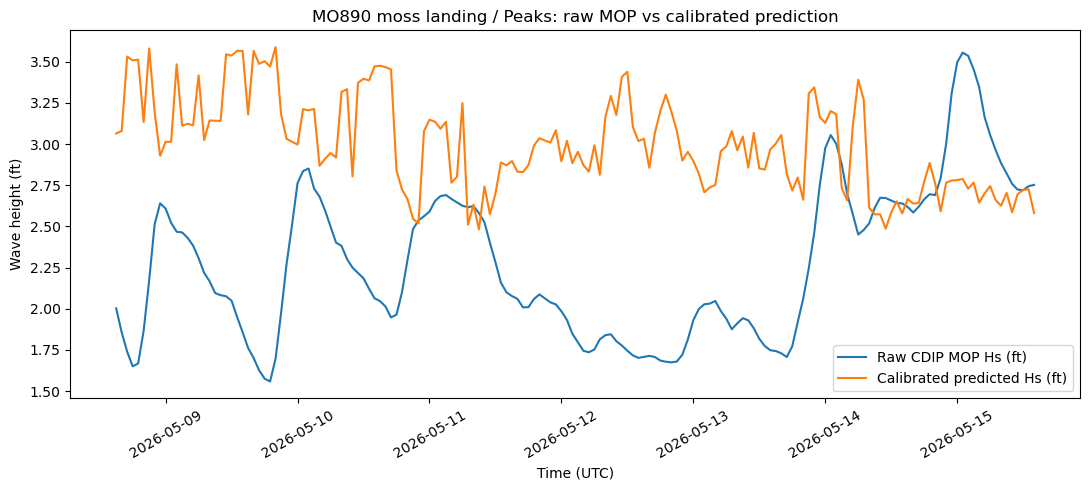

In [56]:
import matplotlib.pyplot as plt

plot_df = prediction_output.copy()
plot_df["wave_time_utc"] = pd.to_datetime(plot_df["wave_time_utc"], utc=True)

plt.figure(figsize=(11, 5))
plt.plot(plot_df["wave_time_utc"], plot_df["hs_mop_ft"], label="Raw CDIP MOP Hs (ft)")
plt.plot(plot_df["wave_time_utc"], plot_df["predicted_hs_ft"], label="Calibrated predicted Hs (ft)")
plt.xlabel("Time (UTC)")
plt.ylabel("Wave height (ft)")
plt.title(f"{TARGET_CDIP_TRANSECT} {TARGET_BREAK_NAME} / {TARGET_SPOT_NAME}: raw MOP vs calibrated prediction")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


# Model performance evaluation

The remaining sections evaluate the model. Because this is a continuous wave-height regression model, the main performance metrics are MAE, RMSE, residual plots, and baseline comparison against raw MOP height.

Accuracy and confusion matrices require discrete classes, so this notebook creates those by binning continuous wave heights into surf-height ranges. Treat the binned accuracy/confusion matrix as an interpretability aid, not as the primary model score.


## 16. Detailed holdout regression metrics

**What this code block does**

This section evaluates the selected model on the chronological holdout rows that were not used in that candidate model's training split.

It computes:

- `mae_ft`: average absolute error in feet. Lower is better.
- `mse_ft2`: mean squared error. Lower is better.
- `rmse_ft`: square root of mean squared error in feet. Lower is better and penalizes large misses more than MAE.
- `median_ae_ft`: median absolute error. Useful when a few large misses distort MAE/RMSE.
- `bias_ft`: average signed error. Positive means the model tends to overpredict; negative means it tends to underpredict.
- `r2`: variance explained on holdout data. Higher is better, but can be unstable on small datasets.
- `max_error_ft`: largest absolute miss in the holdout set.

It also computes the same metrics for raw `hs_mop_ft` as a baseline. The improvement metrics are positive when the calibrated XGBoost model beats raw MOP on the same holdout rows.

**Editable parameters**

- Add extra metrics inside `regression_metrics` if you want more diagnostics.
- Edit `show_cols` to display more or fewer holdout columns.
- Use `TEST_FRACTION_BY_TIME` in Configuration to change how many rows appear in the holdout set.


In [57]:
if selected_validation_df.empty:
    raise ValueError("No holdout rows were available. Increase data size or lower TEST_FRACTION_BY_TIME.")

y_holdout = selected_validation_df["observed_hs_ft"].to_numpy(dtype=float)
y_pred_holdout = selected_validation_df["predicted_hs_ft"].to_numpy(dtype=float)
y_mop_holdout = selected_validation_df["baseline_mop_hs_ft"].to_numpy(dtype=float)

holdout_metrics = {
    "model_used": selected_model_name,
    "n_holdout": int(len(selected_validation_df)),
    **regression_metrics(y_holdout, y_pred_holdout),
    **regression_metrics(y_holdout, y_mop_holdout, prefix="baseline_mop_"),
}

# Improvement is positive when the calibrated model has lower error than raw MOP.
holdout_metrics["mae_improvement_vs_mop_ft"] = holdout_metrics["baseline_mop_mae_ft"] - holdout_metrics["mae_ft"]
holdout_metrics["rmse_improvement_vs_mop_ft"] = holdout_metrics["baseline_mop_rmse_ft"] - holdout_metrics["rmse_ft"]

metrics_table = pd.DataFrame([holdout_metrics]).T.reset_index()
metrics_table.columns = ["metric", "value"]
display(metrics_table)

show_cols = ["datetime_pst", "observed_hs_ft", "predicted_hs_ft", "baseline_mop_hs_ft", "absolute_error_ft", "baseline_absolute_error_ft"]
show_cols = [c for c in show_cols if c in selected_validation_df.columns]
display(selected_validation_df[show_cols].sort_values("datetime_pst"))


,metric,value
0,model_used,target_specific
1,n_holdout,4
2,mae_ft,0.849107
3,mse_ft2,1.068248
4,rmse_ft,1.033561
5,median_ae_ft,0.741052
6,bias_ft,-0.108055
7,metric_rows,4
8,r2,-0.764333
9,max_error_ft,1.71829


,datetime_pst,observed_hs_ft,predicted_hs_ft,baseline_mop_hs_ft,absolute_error_ft,baseline_absolute_error_ft
17,2025-04-17 12:00:00-07:00,2.25,2.687963,1.584946,0.437963,0.665054
18,2025-05-21 12:00:00-07:00,2.00,3.044141,2.468503,1.044141,0.468503
19,2025-09-24 12:00:00-07:00,4.00,2.281710,1.232489,1.718290,2.767511
20,2026-03-27 08:15:00-07:00,3.00,2.803966,2.161632,0.196034,0.838368


## 17. Actual-vs-predicted and residual diagnostics

**What this code block does**

This section creates three diagnostic plots:

1. Actual vs predicted scatter: points closer to the diagonal line are better. The raw MOP baseline is also plotted for comparison.
2. Residuals over time: shows whether errors cluster during certain periods.
3. Residual histogram: shows whether errors are centered around zero and whether there are outliers.

These plots help identify problems that summary metrics can hide. For example, a good MAE can still hide systematic underprediction on larger surf or overprediction on smaller surf.

**Editable parameters**

- `figsize`: controls plot size.
- histogram `bins`: controls residual-bin resolution.
- You can add more residual plots, such as error vs tide, error vs direction, or error vs period.


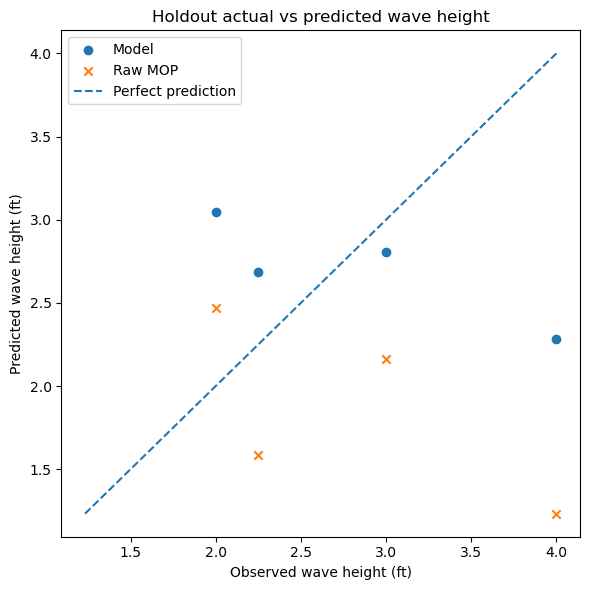

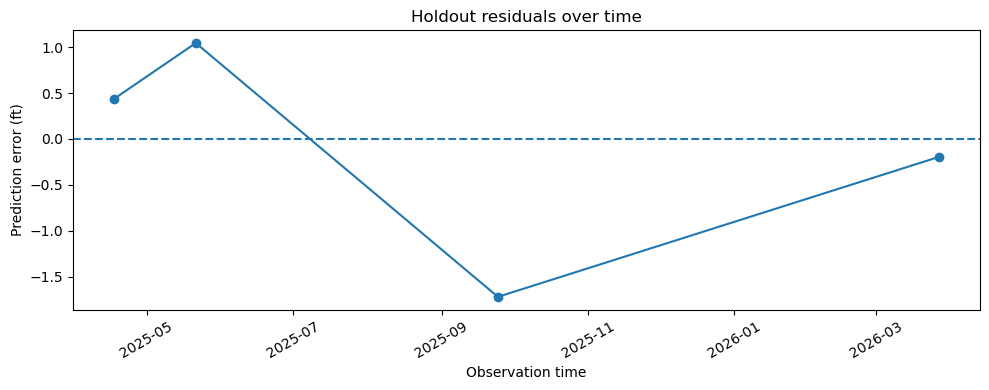

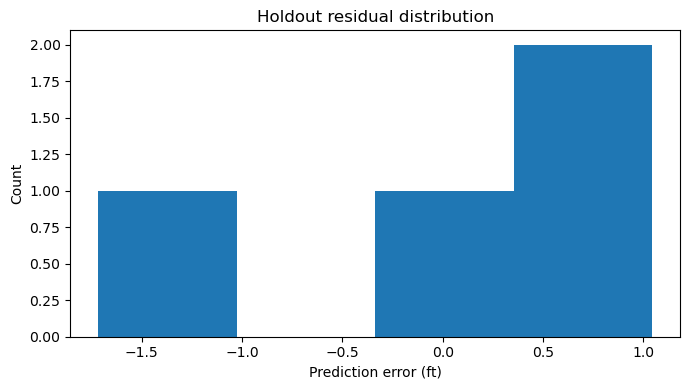

In [58]:
# Actual vs predicted scatter.
plt.figure(figsize=(6, 6))
plt.scatter(selected_validation_df["observed_hs_ft"], selected_validation_df["predicted_hs_ft"], label="Model")
plt.scatter(selected_validation_df["observed_hs_ft"], selected_validation_df["baseline_mop_hs_ft"], marker="x", label="Raw MOP")
min_v = float(np.nanmin([selected_validation_df["observed_hs_ft"].min(), selected_validation_df["predicted_hs_ft"].min(), selected_validation_df["baseline_mop_hs_ft"].min()]))
max_v = float(np.nanmax([selected_validation_df["observed_hs_ft"].max(), selected_validation_df["predicted_hs_ft"].max(), selected_validation_df["baseline_mop_hs_ft"].max()]))
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", label="Perfect prediction")
plt.xlabel("Observed wave height (ft)")
plt.ylabel("Predicted wave height (ft)")
plt.title("Holdout actual vs predicted wave height")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals over time.
resid_df = selected_validation_df.sort_values("datetime_pst").copy()
plt.figure(figsize=(10, 4))
plt.axhline(0, linestyle="--")
plt.plot(resid_df["datetime_pst"], resid_df["error_ft"], marker="o")
plt.xlabel("Observation time")
plt.ylabel("Prediction error (ft)")
plt.title("Holdout residuals over time")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Residual histogram.
plt.figure(figsize=(7, 4))
plt.hist(selected_validation_df["error_ft"].dropna(), bins=min(8, max(3, len(selected_validation_df))))
plt.xlabel("Prediction error (ft)")
plt.ylabel("Count")
plt.title("Holdout residual distribution")
plt.tight_layout()
plt.show()


## 18. XGBoost loss curves

**What this code block does**

This section builds two learning diagnostics.

First, it fits a temporary XGBoost model with an `eval_set` so XGBoost records RMSE after every boosting round. This shows whether adding more trees keeps helping or starts overfitting.

Second, it trains models on progressively larger chronological slices of the training data. This training-size learning curve shows whether more observations are likely to help.

How to read the plots:

- If training RMSE keeps falling while holdout RMSE rises, the model is overfitting.
- If both training and holdout RMSE are high, the model may need better features, more trees, or better labels.
- If holdout RMSE improves as training rows increase, collecting more observations should help.

**Editable parameters**

- `XGBOOST_PARAMS["n_estimators"]`: controls the number of boosting rounds shown.
- `XGBOOST_PARAMS["learning_rate"]`: controls how fast each tree contributes.
- `chronological_learning_curve(..., min_train_rows=5, points=6)`: controls how many training-size checkpoints are plotted.


,boosting_round,train_rmse_ft,holdout_rmse_ft
595,596,0.146012,1.033852
596,597,0.145918,1.034024
597,598,0.145179,1.033795
598,599,0.144775,1.033598
599,600,0.144627,1.033561


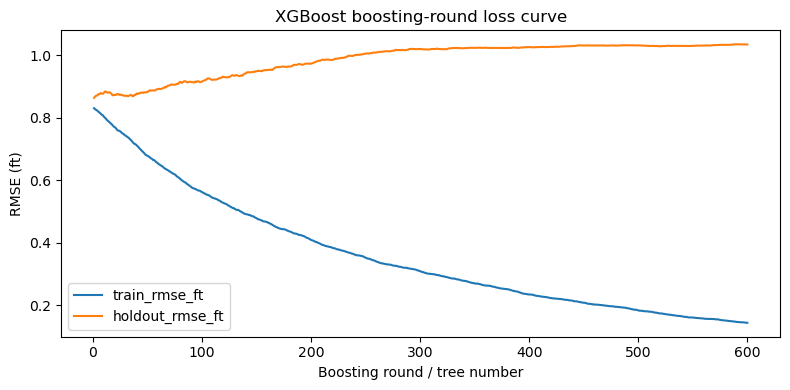

,train_rows,train_rmse_ft,holdout_rmse_ft,train_mae_ft,holdout_mae_ft,n_estimators,max_depth,learning_rate
0,5,0.075751,0.954005,0.052741,0.833065,600,5,0.01
1,7,0.082911,0.779823,0.061530,0.578655,600,5,0.01
2,9,0.129605,0.751363,0.084709,0.691767,600,5,0.01
3,12,0.183617,1.008317,0.124733,0.863095,600,5,0.01
4,14,0.172196,0.963942,0.112666,0.796619,600,5,0.01
5,17,0.144977,1.033351,0.092092,0.821323,600,5,0.01


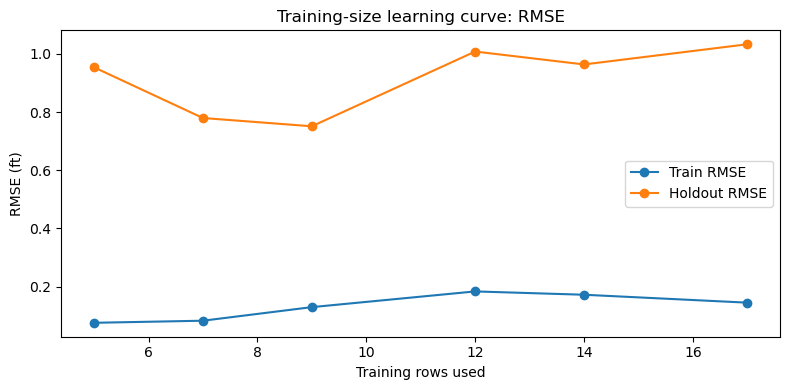

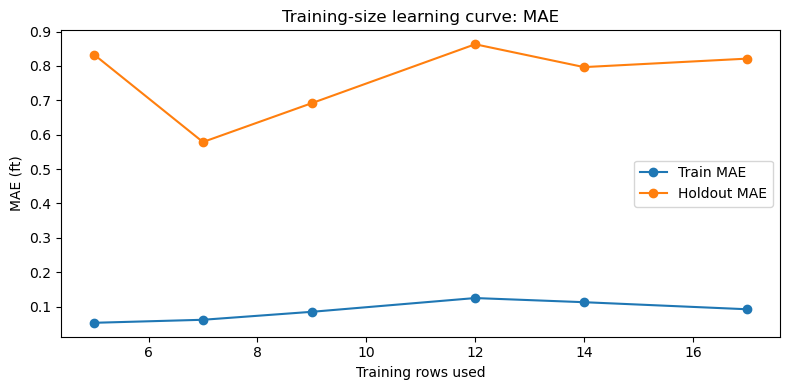

In [59]:
def xgboost_boosting_round_loss_curve(train_df: pd.DataFrame, holdout_df: pd.DataFrame) -> pd.DataFrame:
    """Fit a temporary XGBoost model with an eval_set so we can plot per-round RMSE."""
    if len(train_df) < 5 or holdout_df.empty:
        return pd.DataFrame()

    preprocessor = make_preprocessor()
    X_train_prepared = preprocessor.fit_transform(train_df[ALL_MODEL_FEATURES])
    X_holdout_prepared = preprocessor.transform(holdout_df[ALL_MODEL_FEATURES])
    y_train = train_df["observed_hs_ft"].to_numpy(dtype=float)
    y_holdout = holdout_df["observed_hs_ft"].to_numpy(dtype=float)

    eval_model = make_xgboost_regressor()
    eval_model.fit(
        X_train_prepared,
        y_train,
        eval_set=[(X_train_prepared, y_train), (X_holdout_prepared, y_holdout)],
        verbose=False,
    )
    eval_results = eval_model.evals_result()
    if "validation_0" not in eval_results or "validation_1" not in eval_results:
        return pd.DataFrame()
    metric_name = next(iter(eval_results["validation_0"].keys()))
    train_values = eval_results["validation_0"][metric_name]
    holdout_values = eval_results["validation_1"][metric_name]
    return pd.DataFrame({
        "boosting_round": np.arange(1, len(train_values) + 1),
        f"train_{metric_name}_ft": train_values,
        f"holdout_{metric_name}_ft": holdout_values,
    })


boosting_loss_df = xgboost_boosting_round_loss_curve(selected_train_df, selected_validation_df)
if boosting_loss_df.empty:
    print("Not enough train/holdout rows to build an XGBoost boosting-round loss curve.")
else:
    display(boosting_loss_df.tail())
    metric_cols = [c for c in boosting_loss_df.columns if c != "boosting_round"]
    plt.figure(figsize=(8, 4))
    for col in metric_cols:
        plt.plot(boosting_loss_df["boosting_round"], boosting_loss_df[col], label=col)
    plt.xlabel("Boosting round / tree number")
    plt.ylabel("RMSE (ft)")
    plt.title("XGBoost boosting-round loss curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


def chronological_learning_curve(train_df: pd.DataFrame, holdout_df: pd.DataFrame, min_train_rows: int = 5, points: int = 6) -> pd.DataFrame:
    if len(train_df) < min_train_rows or holdout_df.empty:
        return pd.DataFrame()
    ordered_train = train_df.sort_values("datetime_pst").reset_index(drop=True) if "datetime_pst" in train_df.columns else train_df.reset_index(drop=True)
    sizes = np.unique(np.linspace(min_train_rows, len(ordered_train), num=min(points, len(ordered_train) - min_train_rows + 1), dtype=int))
    rows = []
    for n in sizes:
        sub_train = ordered_train.iloc[:n].copy()
        pipe = make_xgboost_pipeline()
        pipe.fit(sub_train[ALL_MODEL_FEATURES], sub_train["observed_hs_ft"])
        train_pred = np.maximum(pipe.predict(sub_train[ALL_MODEL_FEATURES]), 0.0)
        holdout_pred = np.maximum(pipe.predict(holdout_df[ALL_MODEL_FEATURES]), 0.0)
        rows.append({
            "train_rows": int(n),
            "train_rmse_ft": float(mean_squared_error(sub_train["observed_hs_ft"], train_pred) ** 0.5),
            "holdout_rmse_ft": float(mean_squared_error(holdout_df["observed_hs_ft"], holdout_pred) ** 0.5),
            "train_mae_ft": float(mean_absolute_error(sub_train["observed_hs_ft"], train_pred)),
            "holdout_mae_ft": float(mean_absolute_error(holdout_df["observed_hs_ft"], holdout_pred)),
            "n_estimators": int(XGBOOST_PARAMS["n_estimators"]),
            "max_depth": int(XGBOOST_PARAMS["max_depth"]),
            "learning_rate": float(XGBOOST_PARAMS["learning_rate"]),
        })
    return pd.DataFrame(rows)


loss_curve_df = chronological_learning_curve(selected_train_df, selected_validation_df)
if loss_curve_df.empty:
    print("Not enough train/holdout rows to build a training-size learning curve.")
else:
    display(loss_curve_df)
    plt.figure(figsize=(8, 4))
    plt.plot(loss_curve_df["train_rows"], loss_curve_df["train_rmse_ft"], marker="o", label="Train RMSE")
    plt.plot(loss_curve_df["train_rows"], loss_curve_df["holdout_rmse_ft"], marker="o", label="Holdout RMSE")
    plt.xlabel("Training rows used")
    plt.ylabel("RMSE (ft)")
    plt.title("Training-size learning curve: RMSE")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(loss_curve_df["train_rows"], loss_curve_df["train_mae_ft"], marker="o", label="Train MAE")
    plt.plot(loss_curve_df["train_rows"], loss_curve_df["holdout_mae_ft"], marker="o", label="Holdout MAE")
    plt.xlabel("Training rows used")
    plt.ylabel("MAE (ft)")
    plt.title("Training-size learning curve: MAE")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 19. Wave-height-bin accuracy and confusion matrix

**What this code block does**

This section converts continuous observed and predicted wave heights into surf-height classes, such as `1-2 ft` and `2-3 ft`. It then computes class accuracy, prints a classification report, and displays a confusion matrix.

This is useful for answering questions like: "When the true surf was 2-3 ft, did the model usually predict the same bin, one bin too small, or one bin too large?"

Because the model is a regressor, this binned analysis should not replace MAE/RMSE. It is a secondary view of practical surf-size agreement.

**Editable parameters**

- `WAVE_HEIGHT_CLASS_BINS`: bin edges for converting feet to classes.
- `WAVE_HEIGHT_CLASS_LABELS`: labels for those bins. Must match the number of intervals in `WAVE_HEIGHT_CLASS_BINS`.
- `right=False` in `pd.cut`: controls whether bin edges are left-closed or right-closed.


Wave-height-bin accuracy: 0.250

Classification report:
              precision    recall  f1-score   support

      2-3 ft       0.33      0.50      0.40         2
      3-4 ft       0.00      0.00      0.00         1
      4-6 ft       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.11      0.17      0.13         4
weighted avg       0.17      0.25      0.20         4



,pred_2-3 ft,pred_3-4 ft,pred_4-6 ft
actual_2-3 ft,1,1,0
actual_3-4 ft,1,0,0
actual_4-6 ft,1,0,0


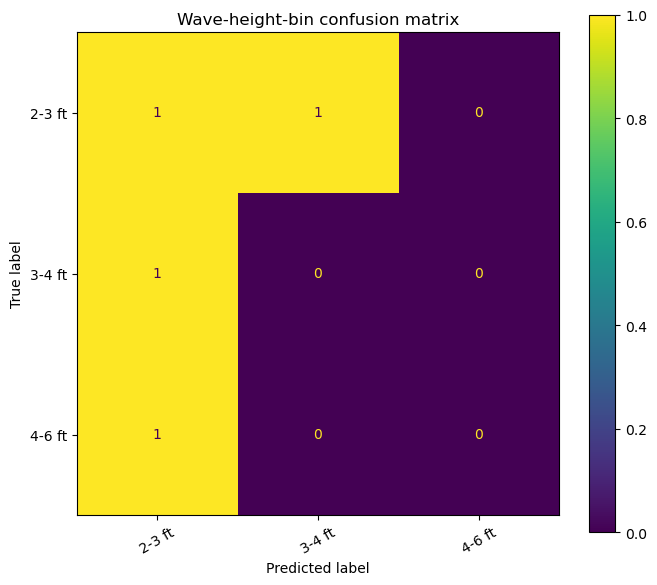

In [60]:
def wave_height_class(values) -> pd.Categorical:
    return pd.cut(values, bins=WAVE_HEIGHT_CLASS_BINS, labels=WAVE_HEIGHT_CLASS_LABELS, right=False, include_lowest=True)

class_eval_df = selected_validation_df.copy()
class_eval_df["observed_class"] = wave_height_class(class_eval_df["observed_hs_ft"])
class_eval_df["predicted_class"] = wave_height_class(class_eval_df["predicted_hs_ft"])
class_eval_df = class_eval_df.dropna(subset=["observed_class", "predicted_class"]).copy()

if class_eval_df.empty:
    print("No holdout rows could be binned for classification-style evaluation.")
else:
    y_true_class = class_eval_df["observed_class"].astype(str)
    y_pred_class = class_eval_df["predicted_class"].astype(str)
    class_accuracy = float(accuracy_score(y_true_class, y_pred_class))
    labels_present = [label for label in WAVE_HEIGHT_CLASS_LABELS if label in set(y_true_class) or label in set(y_pred_class)]
    cm = confusion_matrix(y_true_class, y_pred_class, labels=labels_present)
    confusion_df = pd.DataFrame(cm, index=[f"actual_{x}" for x in labels_present], columns=[f"pred_{x}" for x in labels_present])

    print(f"Wave-height-bin accuracy: {class_accuracy:.3f}")
    print("\nClassification report:")
    print(classification_report(y_true_class, y_pred_class, labels=labels_present, zero_division=0))
    display(confusion_df)

    from sklearn.metrics import ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_present)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, values_format="d")
    plt.title("Wave-height-bin confusion matrix")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 20. Save evaluation outputs

**What this code block does**

This section writes the evaluation results to the local `outputs` folder:

- holdout predictions with observed, predicted, baseline, and error columns;
- regression metrics as JSON; and
- the binned confusion matrix as CSV, if one was produced.

These files are useful for comparing model runs without re-opening the notebook.

**Editable parameters**

- `EVAL_PREDICTIONS_OUTPUT_PATH`: holdout prediction CSV path.
- `EVAL_METRICS_OUTPUT_PATH`: metric JSON path.
- `CONFUSION_MATRIX_OUTPUT_PATH`: confusion matrix CSV path.


In [61]:
selected_validation_df.to_csv(EVAL_PREDICTIONS_OUTPUT_PATH, index=False)
EVAL_METRICS_OUTPUT_PATH.write_text(json.dumps(holdout_metrics, indent=2), encoding="utf-8")

if "confusion_df" in globals() and not confusion_df.empty:
    confusion_df.to_csv(CONFUSION_MATRIX_OUTPUT_PATH)
    print("Saved confusion matrix:", CONFUSION_MATRIX_OUTPUT_PATH.resolve())
else:
    print("No confusion matrix was saved because classification-style evaluation did not produce rows.")

print("Saved holdout predictions:", EVAL_PREDICTIONS_OUTPUT_PATH.resolve())
print("Saved evaluation metrics:", EVAL_METRICS_OUTPUT_PATH.resolve())

Saved confusion matrix: /Users/masonjones/Desktop/explainedNotebook/outputs/mo890_wave_height_bin_confusion_matrix.csv
Saved holdout predictions: /Users/masonjones/Desktop/explainedNotebook/outputs/mo890_model_evaluation_holdout_predictions.csv
Saved evaluation metrics: /Users/masonjones/Desktop/explainedNotebook/outputs/mo890_model_evaluation_metrics.json


## 21. XGBoost feature importance and optional SHAP explanation

**What this code block does**

This section explains which inputs the fitted model used most.

The first part extracts feature names after preprocessing and displays XGBoost's built-in feature importance values. Because categorical columns are one-hot encoded, you may see expanded names for categories.

The optional SHAP section estimates how features contributed to individual predictions and to the model overall. SHAP can be slower than the rest of the notebook, so the code samples up to 100 background rows and 100 explanation rows and skips gracefully if SHAP is unavailable.

**Editable parameters**

- `importance_df.head(25)`: change how many feature-importance rows are displayed.
- `importance_df.head(20)`: change how many bars appear in the plot.
- `max_background = min(100, ...)`: change SHAP background sample size.
- `max_explain = min(100, ...)`: change SHAP explanation sample size.
- `max_display=20`: controls how many features SHAP plots display.


,feature,importance
0,num__swell_direction_deg_sin,0.179840
1,num__swell_direction_deg_cos,0.141663
2,num__long_short_energy_ratio_buoy,0.064422
3,num__tm10_s,0.059955
4,num__dir_pri_deg_buoy_sin,0.056033
5,num__dir_pri_deg_buoy_cos,0.055319
6,num__hs_mop_x_per_pri_mop,0.052420
7,num__swell_height_ft,0.051284
8,num__dir_peak_deg_mop_sin,0.043520
9,num__dir_mean_deg_buoy_sin,0.038341


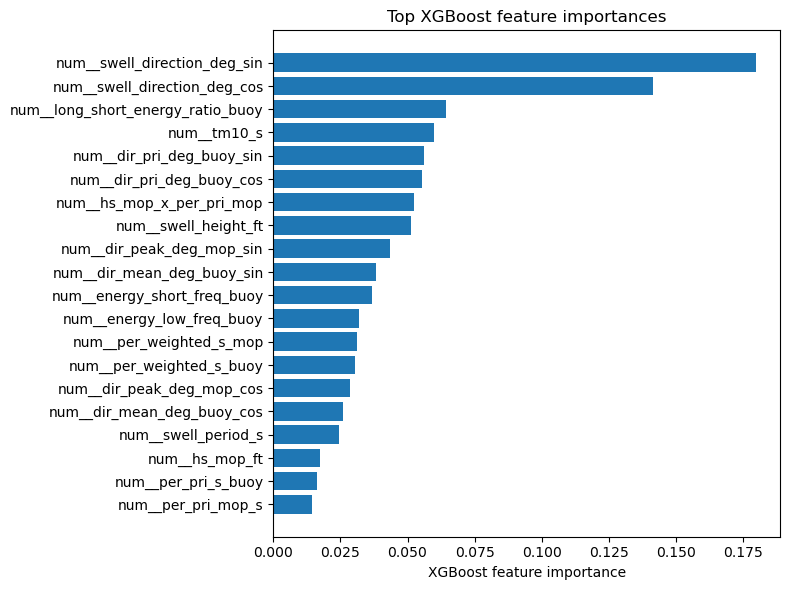

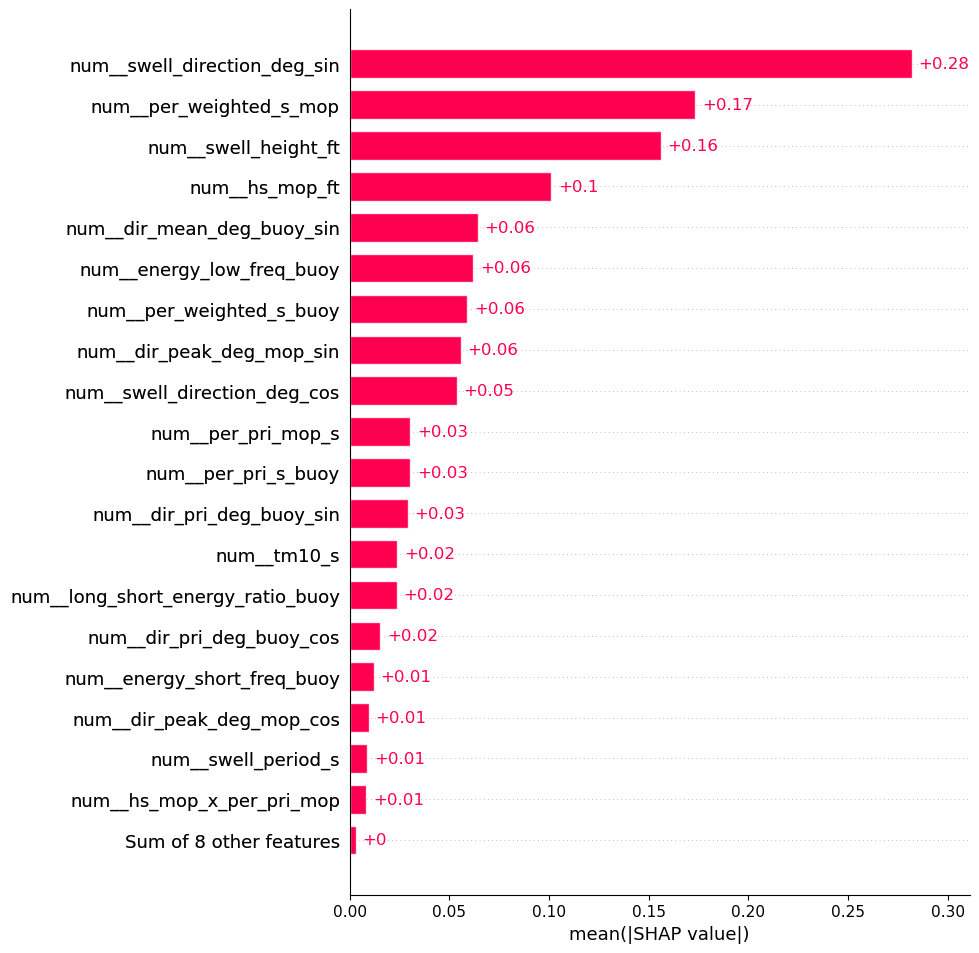

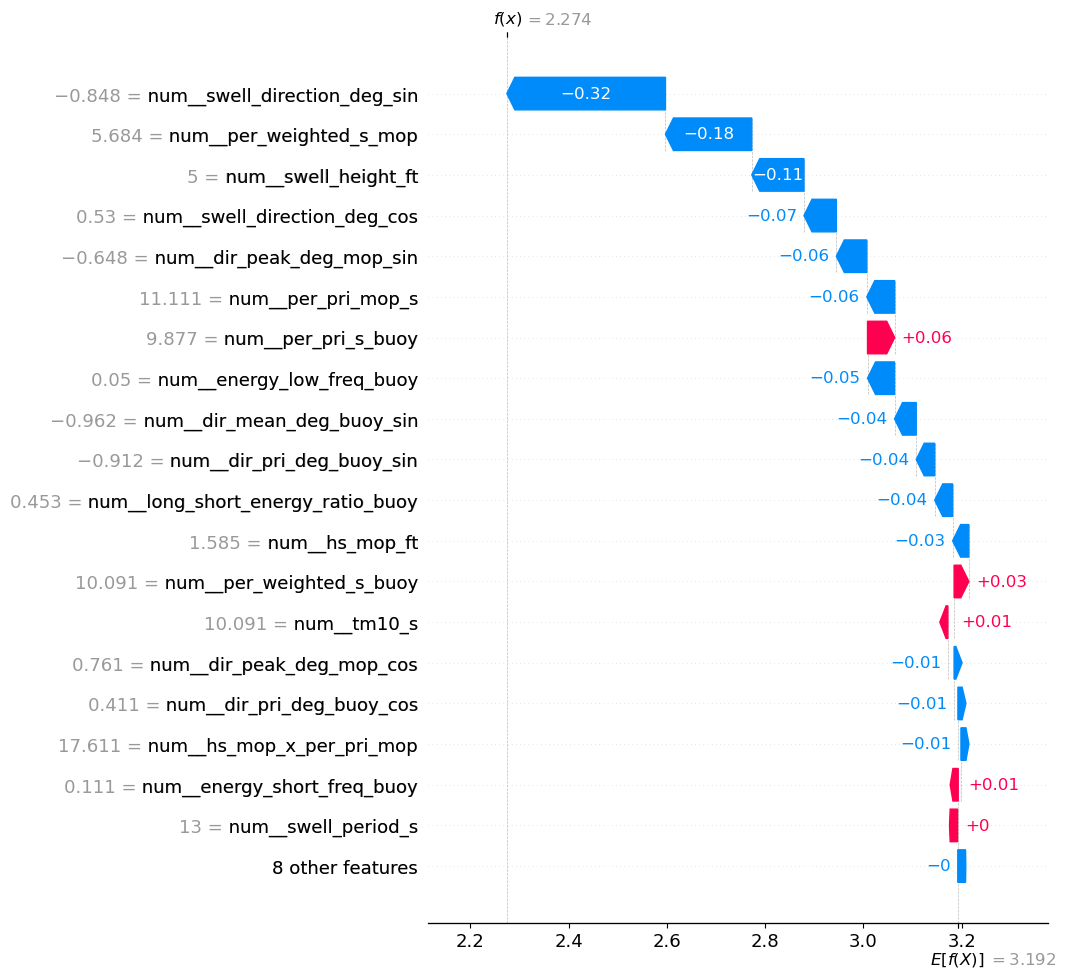

In [62]:
def get_preprocessed_feature_names(pipeline: Pipeline) -> np.ndarray:
    preprocess = pipeline.named_steps["preprocess"]
    try:
        return preprocess.get_feature_names_out()
    except Exception:
        # Fallback names if the installed scikit-learn version cannot expose names.
        n_features = pipeline.named_steps["model"].n_features_in_
        return np.array([f"feature_{i}" for i in range(n_features)])


feature_names = get_preprocessed_feature_names(selected_pipeline)
xgb_model = selected_pipeline.named_steps["model"]
importance = getattr(xgb_model, "feature_importances_", np.array([]))

if len(importance) == len(feature_names):
    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importance})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    display(importance_df.head(25))

    top_importance = importance_df.head(20).sort_values("importance", ascending=True)
    plt.figure(figsize=(8, max(4, 0.3 * len(top_importance))))
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.xlabel("XGBoost feature importance")
    plt.title("Top XGBoost feature importances")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance was not available from the fitted XGBoost model.")

# Optional SHAP explanation. This can be slower than the rest of the notebook,
# so it samples rows and catches errors instead of stopping the workflow.
if shap is None:
    print("Skipping SHAP plots because SHAP is not available in this runtime.")
elif selected_validation_df.empty:
    print("Skipping SHAP plots because there is no validation set.")
else:
    try:
        preprocessor = selected_pipeline.named_steps["preprocess"]
        X_background = preprocessor.transform(selected_train_df[ALL_MODEL_FEATURES])
        X_explain = preprocessor.transform(selected_validation_df[ALL_MODEL_FEATURES])
        if hasattr(X_background, "toarray"):
            X_background = X_background.toarray()
        if hasattr(X_explain, "toarray"):
            X_explain = X_explain.toarray()

        max_background = min(100, X_background.shape[0])
        max_explain = min(100, X_explain.shape[0])
        explainer = shap.Explainer(xgb_model, X_background[:max_background])
        shap_values = explainer(X_explain[:max_explain])
        shap_values.feature_names = list(feature_names)

        shap.plots.bar(shap_values, max_display=20)
        if max_explain > 0:
            shap.plots.waterfall(shap_values[0], max_display=20)
    except Exception as shap_error:
        print("SHAP explanation skipped because an error occurred:", shap_error)


## 22. Interpretation notes

Use these notes when reviewing model output.

- `mae_ft` and `rmse_ft` are the primary regression-error metrics for wave height.
- `baseline_mop_mae_ft` and `baseline_mop_rmse_ft` measure raw CDIP MOP `hs_mop_ft` on the same holdout rows.
- Positive `mae_improvement_vs_mop_ft` or `rmse_improvement_vs_mop_ft` means the calibrated model improved on raw MOP height.
- The confusion matrix is built from height bins, so it measures class agreement rather than exact feet.
- If holdout RMSE rises while training RMSE keeps falling, the model may be overfitting.
- Feature importance and SHAP plots are explanatory diagnostics; they do not replace holdout metrics.
- With a small personal log, treat holdout metrics as an early signal rather than a final production benchmark.
- Because many workbook rows may lack exact session times, tide and wave matching depend on `DEFAULT_OBSERVATION_TIME` except where a time is parsed from notes.
- Parsed workbook swell values are used only as fallbacks where public CDIP MOP fields are unavailable; CDIP values are preferred when present.


## Appendix A. Editable parameter quick reference

This appendix collects the main parameters in one place.

### Site and metadata

- `TARGET_CDIP_TRANSECT`: target CDIP MOP transect. Use `MO890` for the current notebook.
- `TARGET_BREAK_NAME`: break name attached to training and prediction rows.
- `TARGET_SPOT_NAME`: spot name attached to training and prediction rows.
- `TARGET_BREAK_ID`: explicit ID if your local metadata has one. Leave `None` to use fallback matching.
- `TARGET_LAT`, `TARGET_LON`: coordinates for tide-station matching.

### Observation parsing

- `DEFAULT_OBSERVATION_TIME`: fallback time for rows without a parsed session time.
- `KNOWN_DATE_TEXT_REPLACEMENTS`: fixes known date typos.
- `parse_observed_height_from_notes`: advanced edit for custom note formats.
- `parse_swell_text`: advanced edit for custom swell formats.

### Local files

- `LOCAL_DATA_DIR`: input and output root directory.
- `OBSERVATIONS_XLSX`, `OBSERVATIONS_CSV`, `OBSERVATIONS_PARSED_CSV`, `OBSERVATIONS_ALT_CSV`: observation input priority.
- `BREAKS_CSV`, `SPOTS_CSV`, `TRANSECT_TO_BUOY_MAP_CSV`, `TIDE_STATIONS_CSV`: optional metadata files.
- `CACHED_ENRICHED_CSV`: local enriched training cache.
- `PREDICTION_FEATURES_CSV`: optional prediction-input file.

### Enrichment controls

- `USE_CACHED_ENRICHED_IF_AVAILABLE`: use the local enriched cache when possible.
- `FORCE_REENRICH_FROM_RAW`: rebuild enrichment from the raw observation file.
- `SAVE_ENRICHED_CACHE_CSV`: save the enriched table for future runs.
- `FETCH_TIDES_FOR_TRAINING` and `FETCH_TIDES_FOR_PREDICTION`: include tide features.
- `FETCH_BUOY_FOR_TRAINING` and `FETCH_BUOY_FOR_PREDICTION`: include offshore buoy features.
- `TARGET_BUOY_IDS`: buoy fallback order.

### Feature controls

- `BASE_NUMERIC_FEATURES`: numeric input columns.
- `DIRECTION_FEATURES`: degree columns converted to sine/cosine.
- `CATEGORICAL_FEATURES`: categorical columns one-hot encoded.
- `hs_mop_x_tide`, `hs_mop_x_per_pri_mop`, `long_short_energy_ratio_buoy`: interaction features created in `add_model_features`.

### Model controls

- `TEST_FRACTION_BY_TIME`: fraction of newest observations used for holdout validation.
- `MIN_TARGET_ROWS_FOR_TARGET_SPECIFIC_MODEL`: minimum target rows required for target-only model.
- `XGBOOST_PARAMS["n_estimators"]`: number of trees.
- `XGBOOST_PARAMS["max_depth"]`: complexity of each tree.
- `XGBOOST_PARAMS["learning_rate"]`: contribution size of each tree.
- `XGBOOST_PARAMS["subsample"]`: fraction of rows used per tree.
- `XGBOOST_PARAMS["colsample_bytree"]`: fraction of features used per tree.
- `XGBOOST_PARAMS["objective"]`: regression loss objective.
- `XGBOOST_PARAMS["eval_metric"]`: metric used by XGBoost evaluation plots.

### Prediction and evaluation controls

- `PREDICTION_ROWS`: number of recent MOP rows to predict when no prediction CSV is provided.
- `WAVE_HEIGHT_CLASS_BINS` and `WAVE_HEIGHT_CLASS_LABELS`: bins for accuracy and confusion matrix.
- `MODEL_OUTPUT_PATH`, `PREDICTIONS_OUTPUT_PATH`, `EVAL_METRICS_OUTPUT_PATH`, `CONFUSION_MATRIX_OUTPUT_PATH`: output files.

### Suggested tuning workflow

1. Start with the default model and review `mae_ft`, `rmse_ft`, and baseline improvements.
2. Check the residual plots for systematic overprediction or underprediction.
3. Check the boosting-round loss curve for overfitting.
4. If overfitting appears, reduce `max_depth`, reduce `n_estimators`, lower `subsample`, or lower `colsample_bytree`.
5. If the model underfits, increase `n_estimators`, slightly increase `max_depth`, add interaction features, or improve observation labels.
6. Re-run the notebook and compare the saved metrics JSON files across runs.
